# Advanced Exploratory Data Analysis (EDA) & Data Cleaning
## Climate-Driven Disease Forecasting Framework - Sri Lanka

**Objective:** Comprehensive EDA, data cleaning, pattern detection, and preparation for model training.

**Research Context:** This dataset integrates weekly weather variables (temperature, humidity, rainfall) with district-level infectious disease case counts (Leptospirosis, Typhus, Hepatitis A, Chickenpox) from 2020-2025.

**Output:** Clean, analysis-ready dataset with identified patterns and insights for model development.

## 1. IMPORT & SETUP

In [49]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Advanced visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. LOAD & INSPECT DATA

In [50]:
# Load the dataset
df = pd.read_csv('Final_Data_Counts.csv')

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDate Range: {df['start_date'].min()} to {df['end_date'].max()}")
print(f"\nDistricts: {df['district'].nunique()} unique districts")
print(f"Districts: {sorted(df['district'].unique())}")
print(f"\nTime Period: {df['week_id'].min()} to {df['week_id'].max()} weeks")

DATASET OVERVIEW

Dataset Shape: 7275 rows × 49 columns

Memory Usage: 5.30 MB

Date Range: 1/1/2022 to 9/9/2022

Districts: 25 unique districts
Districts: ['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Monaragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']

Time Period: 6 to 296 weeks


In [51]:
# Display first few rows
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
  district  week_id start_date   end_date  T2M_max  T2M_min    T2M_avg  \
0   Ampara        6   2/8/2020  2/14/2020    27.33    26.11  26.777143   
1   Ampara        7  2/15/2020  2/21/2020    27.59    25.99  26.721429   
2   Ampara        8  2/22/2020  2/28/2020    27.45    27.04  27.232857   
3   Ampara        9  2/29/2020   3/6/2020    27.33    26.91  27.172857   
4   Ampara       10   3/7/2020  3/13/2020    28.05    27.45  27.755714   

   T2M_MAX_max  T2M_MAX_min  T2M_MAX_avg  T2M_MIN_max  T2M_MIN_min  \
0        28.35        27.54    27.994286        26.53        24.77   
1        28.74        27.58    28.112857        26.74        24.66   
2        28.76        28.37    28.530000        26.63        25.91   
3        29.76        28.84    29.167143        26.22        25.36   
4        30.31        29.59    29.922857        26.77        25.90   

   T2M_MIN_avg  RH2M_max  RH2M_min   RH2M_avg  PRECTOTCORR_max  \
0    25.765714     82.63     73.90  78.078571        

In [52]:
# Data Types & Info
print("\n" + "="*80)
print("DATA TYPES & STRUCTURE")
print("="*80)
print(df.info())
print("\nData Types Summary:")
print(df.dtypes)


DATA TYPES & STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7275 entries, 0 to 7274
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   district               7275 non-null   object 
 1   week_id                7275 non-null   int64  
 2   start_date             7275 non-null   object 
 3   end_date               7275 non-null   object 
 4   T2M_max                7275 non-null   float64
 5   T2M_min                7275 non-null   float64
 6   T2M_avg                7275 non-null   float64
 7   T2M_MAX_max            7275 non-null   float64
 8   T2M_MAX_min            7275 non-null   float64
 9   T2M_MAX_avg            7275 non-null   float64
 10  T2M_MIN_max            7275 non-null   float64
 11  T2M_MIN_min            7275 non-null   float64
 12  T2M_MIN_avg            7275 non-null   float64
 13  RH2M_max               7275 non-null   float64
 14  RH2M_min               7275 non-

## 3. MISSING VALUES ANALYSIS

In [53]:
# Comprehensive missing values analysis
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type': df.dtypes
}).sort_values('Missing Count', ascending=False)

print("\n" + missing_data.to_string())

# Total missing values
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nTotal Missing Values: {total_missing} out of {total_cells} cells ({total_missing/total_cells*100:.2f}%)")

MISSING VALUES ANALYSIS

                                      Column  Missing Count  Missing Percentage Data Type
Hepatitis A                      Hepatitis A             78                1.07   float64
Typhus                                Typhus             78                1.07   float64
Chickenpox                        Chickenpox             77                1.06   float64
Leptospirosis                  Leptospirosis             75                1.03   float64
T2M_max                              T2M_max              0                0.00   float64
week_id                              week_id              0                0.00     int64
start_date                        start_date              0                0.00    object
end_date                            end_date              0                0.00    object
T2M_MAX_min                      T2M_MAX_min              0                0.00   float64
T2M_MAX_avg                      T2M_MAX_avg              0                

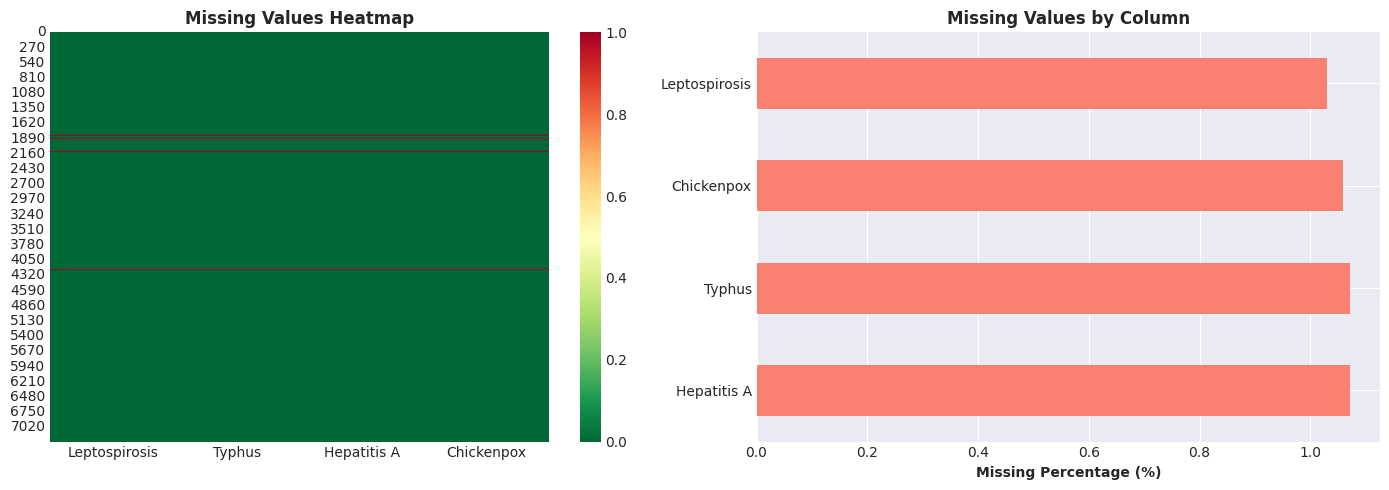

Missing values visualization complete


In [54]:
# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of missing values
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    sns.heatmap(df[missing_cols].isnull(), cbar=True, ax=axes[0], cmap='RdYlGn_r')
    axes[0].set_title('Missing Values Heatmap', fontsize=12, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No missing values found', ha='center', va='center')
    axes[0].set_title('Missing Values Heatmap', fontsize=12, fontweight='bold')

# Bar plot of missing percentages
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', ax=axes[1], color='salmon')
    axes[1].set_xlabel('Missing Percentage (%)', fontweight='bold')
    axes[1].set_title('Missing Values by Column', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No missing values found', ha='center', va='center')
    axes[1].set_title('Missing Values by Column', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Missing values visualization complete")

In [55]:
# Analyze which columns have missing values
print("\nDetailed Missing Value Analysis by Column:")
for col in df.columns:
    if df[col].isnull().any():
        print(f"\n{col}:")
        print(f"  - Missing: {df[col].isnull().sum()} rows")
        print(f"  - Pattern: {df[col].isnull().value_counts().to_dict()}")
        if df[col].dtype != 'object':
            print(f"  - Non-null Range: [{df[col].min()}, {df[col].max()}]")


Detailed Missing Value Analysis by Column:

Leptospirosis:
  - Missing: 75 rows
  - Pattern: {False: 7200, True: 75}
  - Non-null Range: [0.0, 119.0]

Typhus:
  - Missing: 78 rows
  - Pattern: {False: 7197, True: 78}
  - Non-null Range: [0.0, 68.0]

Hepatitis A:
  - Missing: 78 rows
  - Pattern: {False: 7197, True: 78}
  - Non-null Range: [0.0, 12.0]

Chickenpox:
  - Missing: 77 rows
  - Pattern: {False: 7198, True: 77}
  - Non-null Range: [0.0, 41.0]


## 4. HANDLE MISSING VALUES

**Strategy:**
- **Disease counts (Leptospirosis, Typhus, Hepatitis A, Chickenpox):** Forward fill + backward fill (assumes disease counts follow temporal continuity)
- **Weather/Climate variables:** KNN imputation (maintains spatial-temporal relationships)
- **Last resort:** Rows with >30% missing will be removed

In [56]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Disease columns
disease_cols = ['Leptospirosis', 'Typhus', 'Hepatitis A', 'Chickenpox']

# Step 1: Handle disease counts with forward fill + backward fill by district
print("\nStep 1: Imputing disease counts by district...")
for col in disease_cols:
    before = df_clean[col].isnull().sum()
    # Forward fill within each district
    df_clean[col] = df_clean.groupby('district')[col].fillna(method='ffill')
    # Backward fill remaining
    df_clean[col] = df_clean.groupby('district')[col].fillna(method='bfill')
    # If still missing, use 0 (no cases reported)
    df_clean[col] = df_clean[col].fillna(0)
    after = df_clean[col].isnull().sum()
    print(f"  {col}: {before} → {after} missing values")

print("\nDisease counts imputed successfully")

HANDLING MISSING VALUES

Step 1: Imputing disease counts by district...
  Leptospirosis: 75 → 0 missing values
  Typhus: 78 → 0 missing values
  Hepatitis A: 78 → 0 missing values
  Chickenpox: 77 → 0 missing values

Disease counts imputed successfully


In [57]:
# Check for remaining missing values
remaining_missing = df_clean.isnull().sum()
print("\nRemaining Missing Values:")
print(remaining_missing[remaining_missing > 0])

if remaining_missing.sum() == 0:
    print("\nAll missing values have been successfully handled!")
else:
    print(f"\n⚠ Still {remaining_missing.sum()} missing values to address")


Remaining Missing Values:
Series([], dtype: int64)

All missing values have been successfully handled!


## 5. DATA TYPE VALIDATION & CONVERSION

In [58]:
# Convert date columns
print("="*80)
print("DATA TYPE CONVERSION")
print("="*80)

# Parse dates
df_clean['start_date'] = pd.to_datetime(df_clean['start_date'])
df_clean['end_date'] = pd.to_datetime(df_clean['end_date'])

# Convert district to category
df_clean['district'] = df_clean['district'].astype('category')

# Convert boolean columns
boolean_cols = ['monsoon_IM2', 'monsoon_NE', 'monsoon_SW']
for col in boolean_cols:
    # Clean whitespace and convert
    df_clean[col] = df_clean[col].astype(str).str.strip().map({'True': True, 'False': False})

# Ensure disease counts are integers
for col in disease_cols:
    df_clean[col] = df_clean[col].astype('int64')

print("\nData Types After Conversion:")
print(df_clean.dtypes)
print("\nData type conversion complete")

DATA TYPE CONVERSION

Data Types After Conversion:
district                       category
week_id                           int64
start_date               datetime64[ns]
end_date                 datetime64[ns]
T2M_max                         float64
T2M_min                         float64
T2M_avg                         float64
T2M_MAX_max                     float64
T2M_MAX_min                     float64
T2M_MAX_avg                     float64
T2M_MIN_max                     float64
T2M_MIN_min                     float64
T2M_MIN_avg                     float64
RH2M_max                        float64
RH2M_min                        float64
RH2M_avg                        float64
PRECTOTCORR_max                 float64
PRECTOTCORR_min                 float64
PRECTOTCORR_avg                 float64
Duration                         object
month                             int64
monsoon_IM2                        bool
monsoon_NE                         bool
monsoon_SW                   

In [59]:
# Validate data ranges
print("\n" + "="*80)
print("DATA RANGE VALIDATION")
print("="*80)

# Check temperature ranges (should be reasonable for Sri Lanka: 15-35°C)
temp_cols = [col for col in df_clean.columns if 'T2M' in col and 'lag' not in col]
print("\nTemperature Variables (°C) - Expected range: 15-35°C")
for col in temp_cols:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    print(f"  {col}: [{min_val:.2f}, {max_val:.2f}]")

# Check humidity (should be 0-100%)
humidity_cols = [col for col in df_clean.columns if 'RH2M' in col and 'lag' not in col]
print("\nHumidity Variables (%) - Expected range: 0-100%")
for col in humidity_cols:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    print(f"  {col}: [{min_val:.2f}, {max_val:.2f}]")

# Check precipitation (non-negative)
precip_cols = [col for col in df_clean.columns if 'PRECTOTCORR' in col and 'lag' not in col]
print("\nPrecipitation Variables (mm) - Expected range: ≥0")
for col in precip_cols:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    print(f"  {col}: [{min_val:.2f}, {max_val:.2f}]")


DATA RANGE VALIDATION

Temperature Variables (°C) - Expected range: 15-35°C
  T2M_max: [20.80, 32.38]
  T2M_min: [18.46, 31.35]
  T2M_avg: [20.19, 31.61]
  T2M_MAX_max: [25.30, 39.71]
  T2M_MAX_min: [21.27, 36.87]
  T2M_MAX_avg: [23.94, 37.86]
  T2M_MIN_max: [16.18, 30.55]
  T2M_MIN_min: [13.39, 29.09]
  T2M_MIN_avg: [15.16, 29.95]

Humidity Variables (%) - Expected range: 0-100%
  RH2M_max: [62.07, 96.88]
  RH2M_min: [57.99, 93.20]
  RH2M_avg: [60.07, 94.44]

Precipitation Variables (mm) - Expected range: ≥0
  PRECTOTCORR_max: [0.00, 250.28]
  PRECTOTCORR_min: [0.00, 17.30]
  PRECTOTCORR_avg: [0.00, 54.40]


## 6. OUTLIER DETECTION

In [60]:
# Outlier detection using IQR method
print("="*80)
print("OUTLIER DETECTION (IQR Method)")
print("="*80)

def detect_outliers_iqr(data, col_name, multiplier=1.5):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = data[(data[col_name] < lower_bound) | (data[col_name] > upper_bound)]
    return len(outliers), lower_bound, upper_bound, outliers

# Check outliers in numerical columns
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['week_id']]

outlier_summary = []
for col in numerical_cols:
    count, lower, upper, _ = detect_outliers_iqr(df_clean, col)
    outlier_summary.append({
        'Column': col,
        'Outlier Count': count,
        'Percentage': f"{count/len(df_clean)*100:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier Count', ascending=False)
print("\n" + outlier_df.to_string())

OUTLIER DETECTION (IQR Method)



                   Column  Outlier Count Percentage Lower Bound Upper Bound
39            Hepatitis A           1166     16.03%        0.00        0.00
13        PRECTOTCORR_min            723      9.94%       -1.89        3.23
38                 Typhus            576      7.92%       -1.50        2.50
37          Leptospirosis            533      7.33%      -11.00       21.00
40             Chickenpox            499      6.86%       -7.50       12.50
12        PRECTOTCORR_max            402      5.53%      -19.95       42.85
14        PRECTOTCORR_avg            346      4.76%       -8.83       18.05
23  PRECTOTCORR_avg_lag_5            346      4.76%       -8.84       18.05
24  PRECTOTCORR_avg_lag_6            346      4.76%       -8.86       18.06
21  PRECTOTCORR_avg_lag_3            346      4.76%       -8.81       18.03
22  PRECTOTCORR_avg_lag_4            346      4.76%       -8.83       18.04
19  PRECTOTCORR_avg_lag_1            346      4.76%       -8.83       18.05
20  PRECTOT

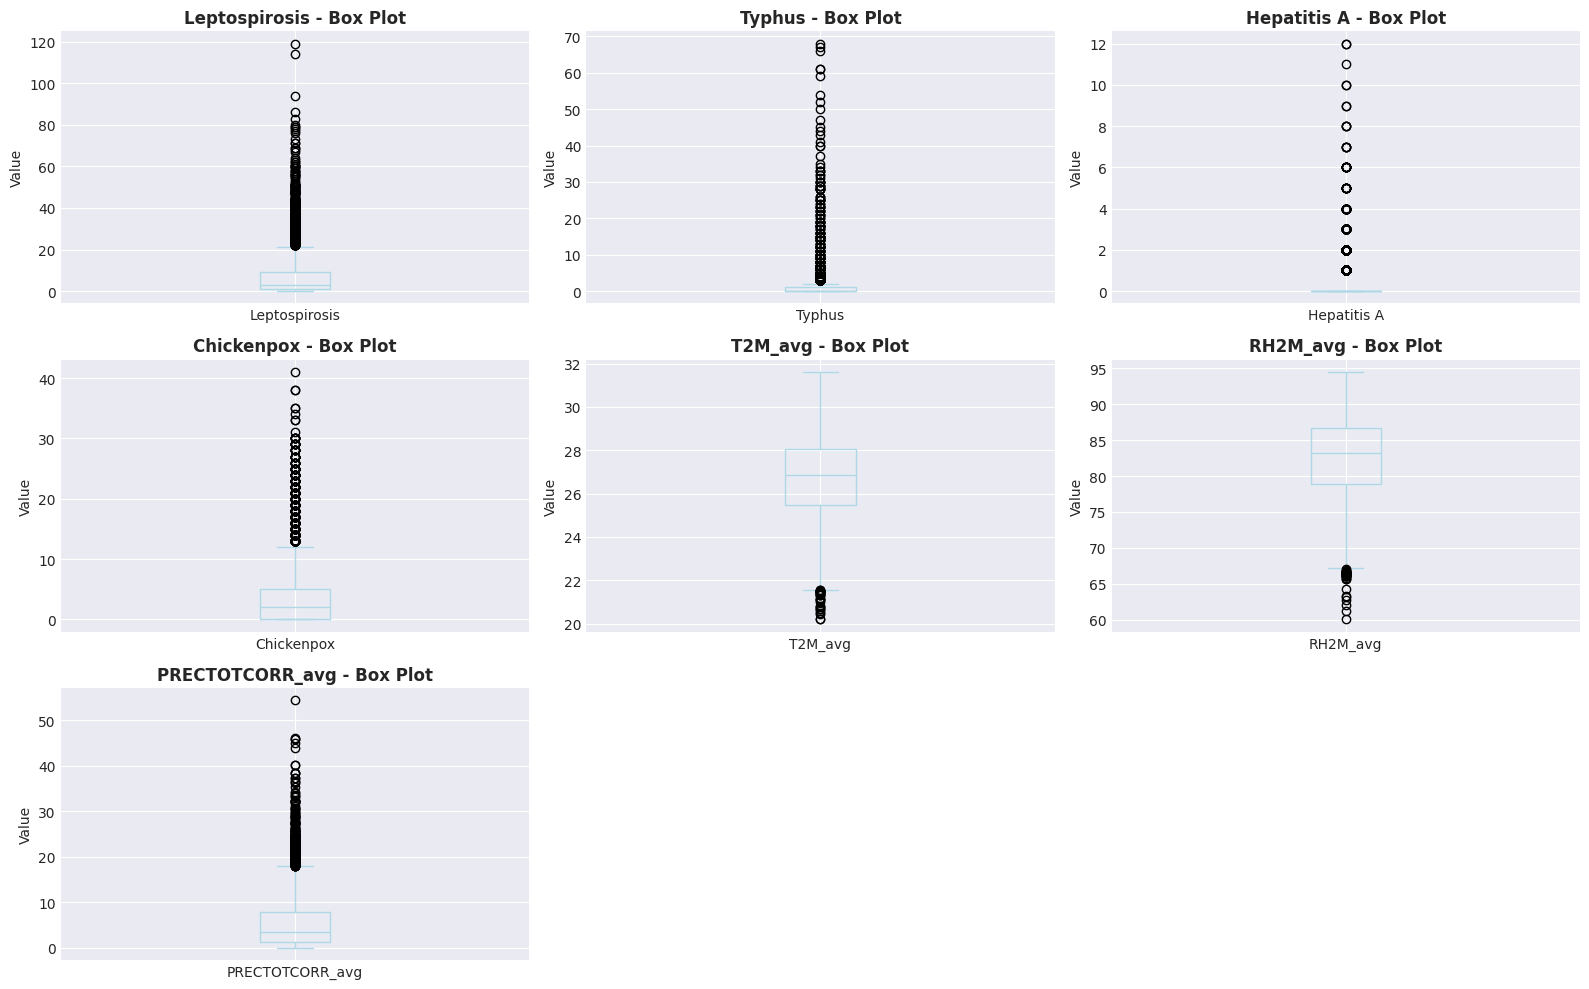

Outlier visualization complete


In [61]:
# Visualize outliers
fig = plt.figure(figsize=(16, 10))
cols_to_plot = ['Leptospirosis', 'Typhus', 'Hepatitis A', 'Chickenpox', 
                'T2M_avg', 'RH2M_avg', 'PRECTOTCORR_avg']

for idx, col in enumerate(cols_to_plot, 1):
    ax = plt.subplot(3, 3, idx)
    df_clean[col].plot(kind='box', ax=ax, color='lightblue')
    ax.set_title(f'{col} - Box Plot', fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()
print("Outlier visualization complete")

In [62]:
# Decision on outliers: Keep them (they represent real disease outbreak or extreme weather)
# Outliers in disease counts may indicate actual outbreaks
# Outliers in weather may indicate extreme events
# These are valuable for modeling

print("\n" + "="*80)
print("OUTLIER HANDLING DECISION")
print("="*80)
print("""
Decision: RETAIN OUTLIERS

Rationale:
1. Disease outbreaks (high case counts) are important signals for modeling
2. Extreme weather events (rainfall spikes) are relevant climate factors
3. Removing outliers would lose valuable information about rare but important events
4. ML models (XGBoost, LightGBM) are robust to outliers
5. SHAP analysis can explain outlier impacts

Action: No rows removed for outliers
""")


OUTLIER HANDLING DECISION

Decision: RETAIN OUTLIERS

Rationale:
1. Disease outbreaks (high case counts) are important signals for modeling
2. Extreme weather events (rainfall spikes) are relevant climate factors
3. Removing outliers would lose valuable information about rare but important events
4. ML models (XGBoost, LightGBM) are robust to outliers
5. SHAP analysis can explain outlier impacts

Action: No rows removed for outliers



## 7. DESCRIPTIVE STATISTICS

In [63]:
# Overall descriptive statistics
print("="*80)
print("DESCRIPTIVE STATISTICS - OVERALL")
print("="*80)

print("\n" + df_clean.describe().round(2).to_string())

DESCRIPTIVE STATISTICS - OVERALL

       week_id           start_date             end_date  T2M_max  T2M_min  T2M_avg  T2M_MAX_max  T2M_MAX_min  T2M_MAX_avg  T2M_MIN_max  T2M_MIN_min  T2M_MIN_avg  RH2M_max  RH2M_min  RH2M_avg  PRECTOTCORR_max  PRECTOTCORR_min  PRECTOTCORR_avg    month  week_number  sin_week  cos_week  PRECTOTCORR_avg_lag_1  PRECTOTCORR_avg_lag_2  PRECTOTCORR_avg_lag_3  PRECTOTCORR_avg_lag_4  PRECTOTCORR_avg_lag_5  PRECTOTCORR_avg_lag_6  T2M_avg_lag_1  T2M_avg_lag_2  T2M_avg_lag_3  T2M_avg_lag_4  T2M_avg_lag_5  T2M_avg_lag_6  RH2M_avg_lag_1  RH2M_avg_lag_2  RH2M_avg_lag_3  RH2M_avg_lag_4  RH2M_avg_lag_5  RH2M_avg_lag_6  Leptospirosis   Typhus  Hepatitis A  Chickenpox
count  7275.00                 7275                 7275  7275.00  7275.00  7275.00      7275.00      7275.00      7275.00      7275.00      7275.00      7275.00   7275.00   7275.00   7275.00          7275.00          7275.00          7275.00  7275.00      7275.00   7275.00   7275.00                7275.00 

In [64]:
# Disease statistics by district
print("\n" + "="*80)
print("DISEASE STATISTICS BY DISTRICT")
print("="*80)

for disease in disease_cols:
    print(f"\n{disease.upper()}:")
    disease_by_district = df_clean.groupby('district')[disease].agg([
        'count', 'mean', 'std', 'min', 'max', 'sum'
    ]).round(2)
    print(disease_by_district.sort_values('sum', ascending=False))


DISEASE STATISTICS BY DISTRICT

LEPTOSPIROSIS:
              count   mean    std  min  max   sum
district                                         
Ratnapura       291  25.99  16.89    0  114  7563
Galle           291  16.80  12.04    0   80  4888
Kalutara        291  15.82  13.20    0   73  4603
Kegalle         291  14.98  11.24    0   56  4360
Kurunegala      291  11.47  13.42    0   94  3338
Gampaha         291   9.97  10.06    0   62  2901
Matara          291   9.04   6.73    0   42  2632
Monaragala      291   8.62   9.23    0   53  2507
Colombo         291   7.56   6.34    0   32  2199
Hambantota      291   7.24   5.84    0   36  2107
Badulla         291   6.98   4.81    0   29  2032
Anuradhapura    291   6.26   6.20    0   34  1821
Kandy           291   5.68   4.64    0   37  1653
Polonnaruwa     291   4.31   4.52    0   28  1253
Puttalam        291   2.96   4.37    0   26   862
Matale          291   2.92   2.98    0   19   851
Ampara          291   2.80   3.67    0   25   814
Nu

In [65]:
# Weather statistics by monsoon season
print("\n" + "="*80)
print("WEATHER STATISTICS BY MONSOON SEASON")
print("="*80)

# Determine dominant monsoon
df_clean['monsoon_season'] = 'No Monsoon'
df_clean.loc[df_clean['monsoon_NE'] == True, 'monsoon_season'] = 'NE Monsoon'
df_clean.loc[df_clean['monsoon_SW'] == True, 'monsoon_season'] = 'SW Monsoon'
df_clean.loc[df_clean['monsoon_IM2'] == True, 'monsoon_season'] = 'IM2'

monsoon_stats = df_clean.groupby('monsoon_season')[['T2M_avg', 'RH2M_avg', 'PRECTOTCORR_avg']].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("\n" + monsoon_stats.to_string())


WEATHER STATISTICS BY MONSOON SEASON

               T2M_avg                            RH2M_avg                            PRECTOTCORR_avg                          
                 count   mean   std    min    max    count   mean   std    min    max           count   mean   std   min    max
monsoon_season                                                                                                                 
IM2               1100  26.30  1.52  21.34  29.18     1100  84.87  4.10  71.15  93.89            1100  10.84  7.58  0.02  54.40
NE Monsoon        1700  25.32  1.65  20.19  28.40     1700  84.39  5.11  67.61  94.44            1700   5.71  6.25  0.00  45.02
No Monsoon        1300  27.42  1.71  22.29  31.61     1300  79.65  5.26  60.07  91.53            1300   4.59  4.75  0.00  36.40
SW Monsoon        3175  27.26  1.73  21.80  31.26     3175  81.95  5.29  61.30  92.60            3175   3.98  4.03  0.00  32.12


---

## PHASE 2: EXPLORATORY DATA ANALYSIS & PATTERN DETECTION

This phase focuses on:
- Distribution Analysis (disease & weather variables)
- Correlation Analysis (climate-disease relationships)
- Temporal Patterns (trends, autocorrelation)
- Seasonality Analysis (monsoon effects)
- Lag Feature Effectiveness
- Time-Series Decomposition
- Anomaly Detection

---

## 8. DISEASE DISTRIBUTION ANALYSIS

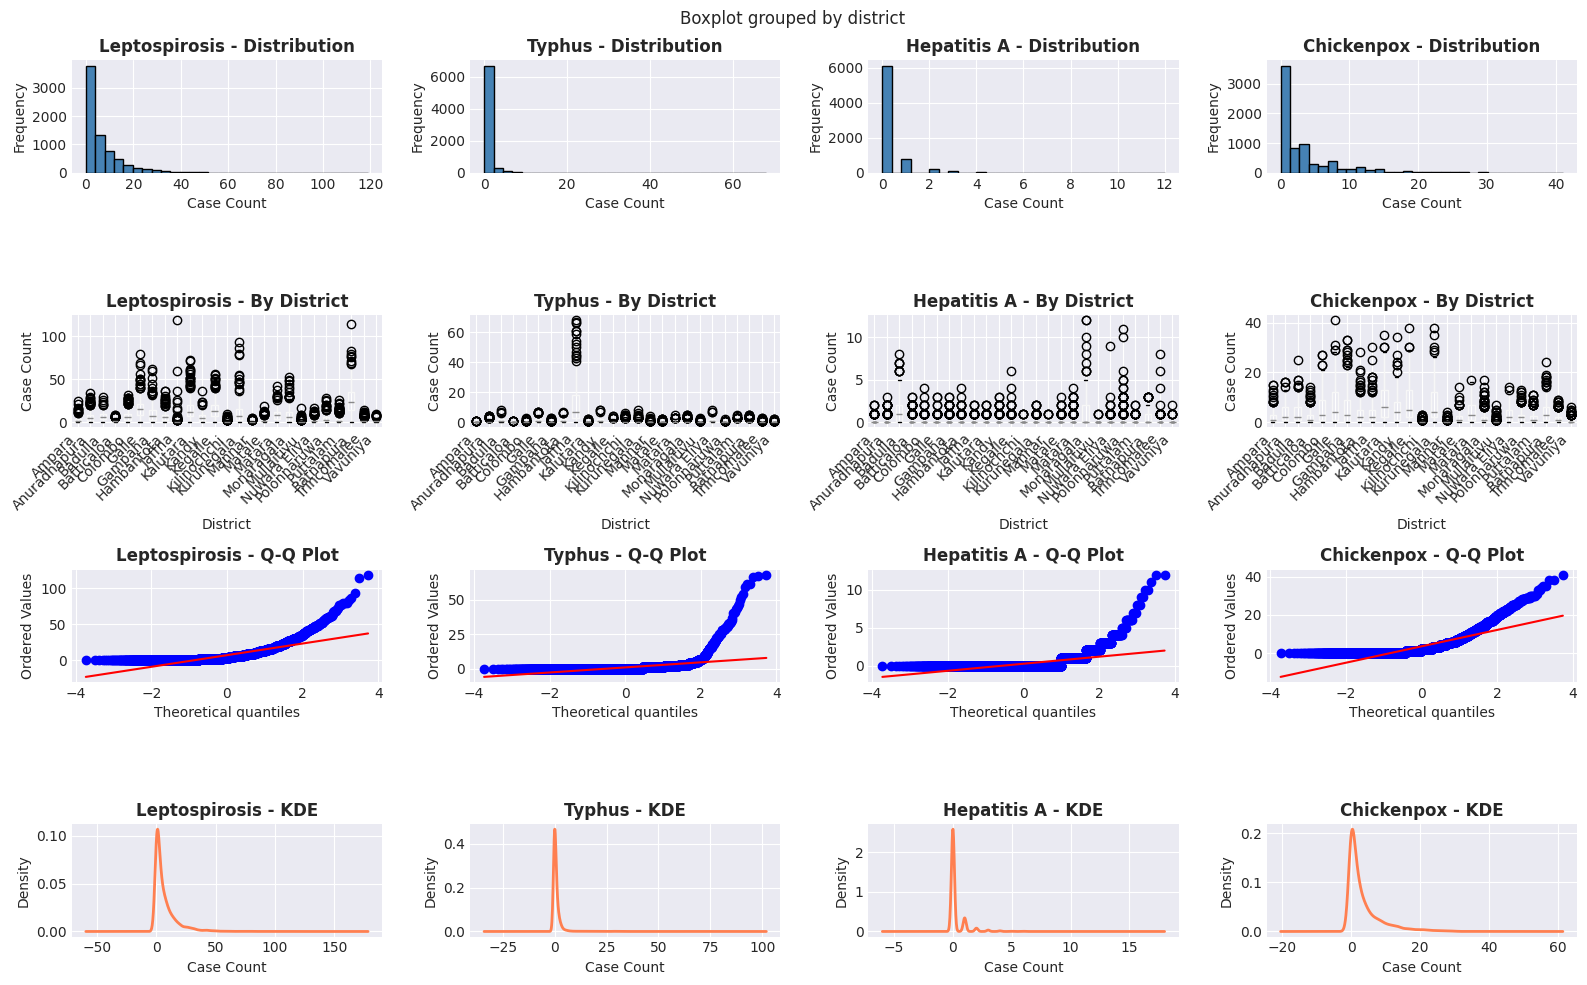

Disease distribution analysis complete


In [66]:
# Distribution plots for disease counts
fig = plt.figure(figsize=(16, 10))

for idx, disease in enumerate(disease_cols, 1):
    # Histogram
    ax1 = plt.subplot(4, 4, idx)
    df_clean[disease].hist(bins=30, ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title(f'{disease} - Distribution', fontweight='bold')
    ax1.set_xlabel('Case Count')
    ax1.set_ylabel('Frequency')
    
    # Box plot
    ax2 = plt.subplot(4, 4, idx + 4)
    df_clean.boxplot(column=disease, ax=ax2, by='district')
    ax2.set_title(f'{disease} - By District', fontweight='bold')
    ax2.set_xlabel('District')
    ax2.set_ylabel('Case Count')
    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    
    # Q-Q plot
    ax3 = plt.subplot(4, 4, idx + 8)
    stats.probplot(df_clean[disease], dist='norm', plot=ax3)
    ax3.set_title(f'{disease} - Q-Q Plot', fontweight='bold')
    
    # KDE
    ax4 = plt.subplot(4, 4, idx + 12)
    df_clean[disease].plot(kind='density', ax=ax4, color='coral', linewidth=2)
    ax4.set_title(f'{disease} - KDE', fontweight='bold')
    ax4.set_xlabel('Case Count')

plt.tight_layout()
plt.show()

print("Disease distribution analysis complete")

In [67]:
# Statistical tests for normality
print("\n" + "="*80)
print("NORMALITY TESTS (Shapiro-Wilk) - Disease Counts")
print("="*80)

normality_results = []
for disease in disease_cols:
    stat, p_value = stats.shapiro(df_clean[disease])
    normality_results.append({
        'Disease': disease,
        'Statistic': f"{stat:.4f}",
        'P-Value': f"{p_value:.6f}",
        'Normal': 'Yes' if p_value > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)
print("\n" + normality_df.to_string(index=False))
print("\nInterpretation: p-value > 0.05 suggests normal distribution")


NORMALITY TESTS (Shapiro-Wilk) - Disease Counts

      Disease Statistic  P-Value Normal
Leptospirosis    0.6836 0.000000     No
       Typhus    0.2489 0.000000     No
  Hepatitis A    0.3681 0.000000     No
   Chickenpox    0.7093 0.000000     No

Interpretation: p-value > 0.05 suggests normal distribution


In [68]:
# Disease summary statistics by district
print("\n" + "="*80)
print("DISEASE BURDEN BY DISTRICT")
print("="*80)

district_disease_summary = df_clean.groupby('district')[disease_cols].agg([
    'sum', 'mean', 'std'
]).round(2)

print("\nTotal Cases by District:")
print(df_clean.groupby('district')[disease_cols].sum().sort_values(disease_cols[0], ascending=False))

print("\n\nAverage Cases per Week by District:")
print(df_clean.groupby('district')[disease_cols].mean().round(2).sort_values(disease_cols[0], ascending=False))


DISEASE BURDEN BY DISTRICT

Total Cases by District:
              Leptospirosis  Typhus  Hepatitis A  Chickenpox
district                                                    
Ratnapura              7563     213          125        1214
Galle                  4888     396           38        2152
Kalutara               4603      33           40        2396
Kegalle                4360     171           74        2378
Kurunegala             3338     183           47        2165
Gampaha                2901      46           69        1720
Matara                 2632     129           66        1237
Monaragala             2507     179          331         545
Colombo                2199      23           43        1652
Hambantota             2107     354           59        1009
Badulla                2032     360          414        1147
Anuradhapura           1821     166           58        1012
Kandy                  1653     354           58        1463
Polonnaruwa            1253    

## 9. WEATHER DISTRIBUTION ANALYSIS

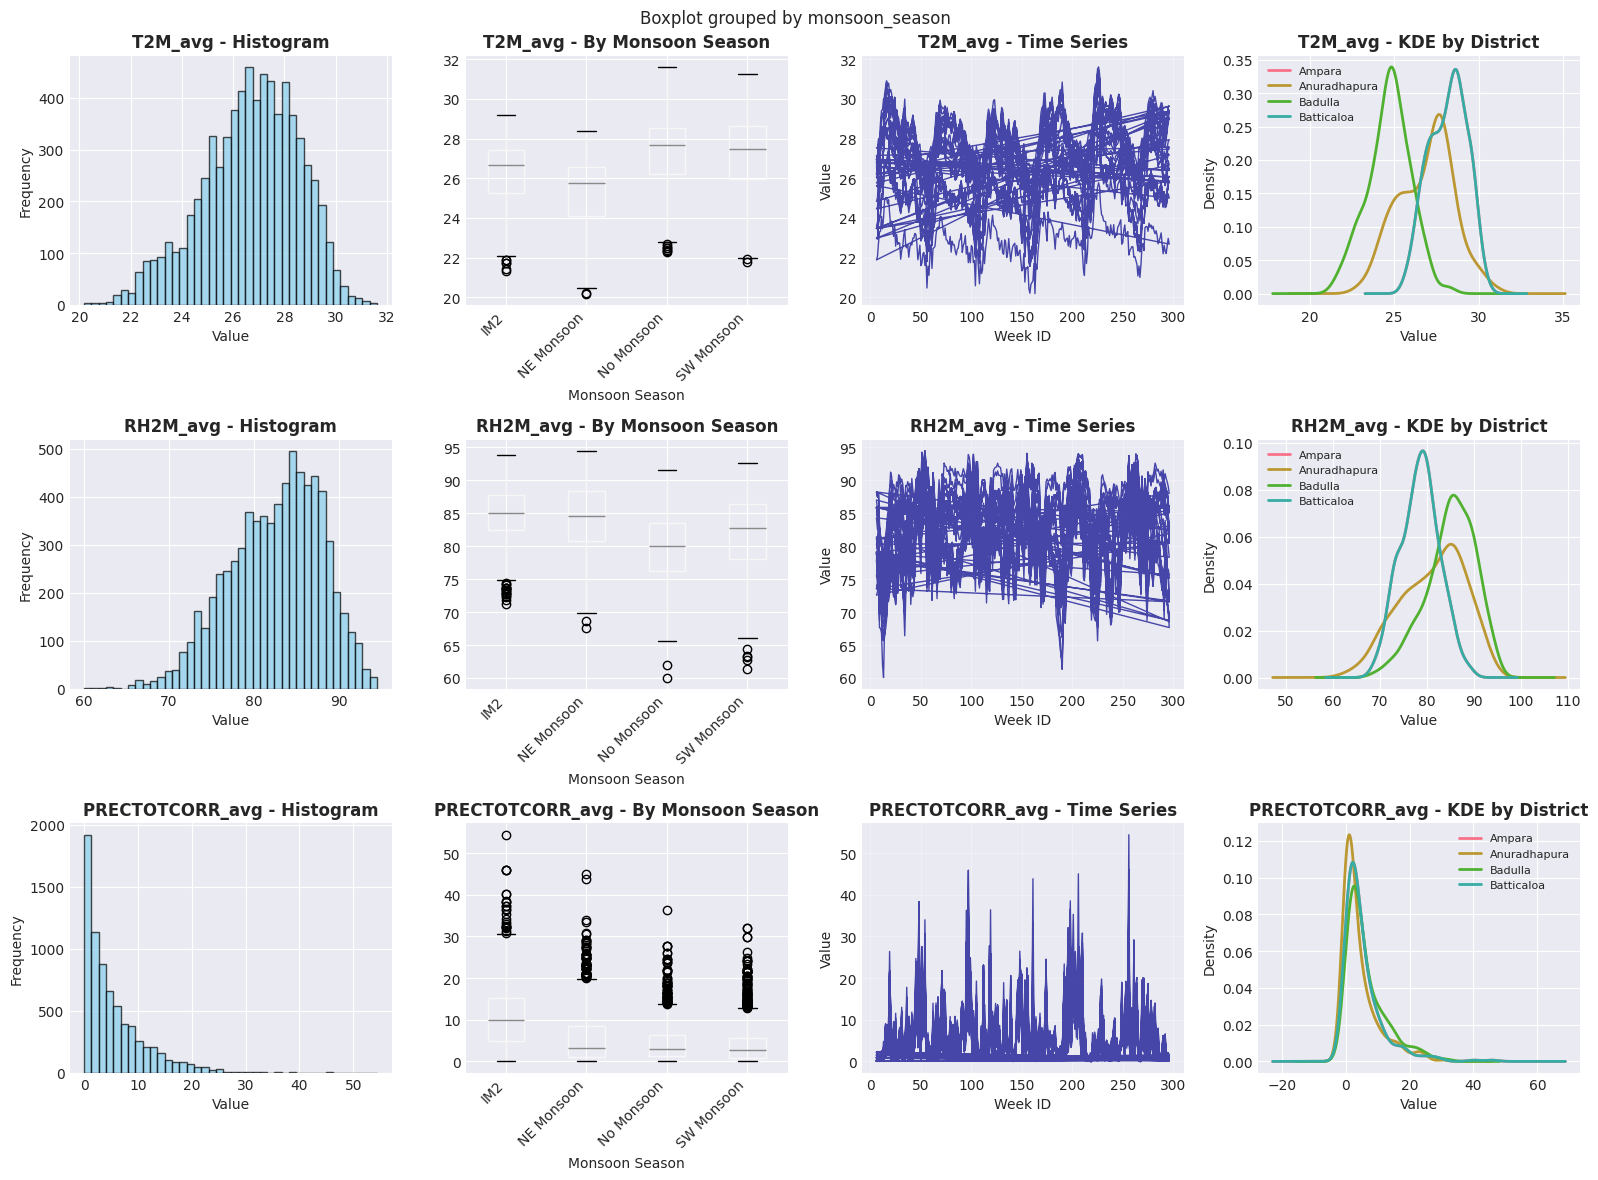

Weather distribution analysis complete


In [69]:
# Weather variables distribution
weather_vars = ['T2M_avg', 'RH2M_avg', 'PRECTOTCORR_avg']
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for idx, var in enumerate(weather_vars):
    # Histogram with KDE
    ax = axes[idx, 0]
    df_clean[var].hist(bins=40, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{var} - Histogram', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    
    # Box plot by monsoon
    ax = axes[idx, 1]
    df_clean.boxplot(column=var, by='monsoon_season', ax=ax)
    ax.set_title(f'{var} - By Monsoon Season', fontweight='bold')
    ax.set_xlabel('Monsoon Season')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')
    
    # Time series
    ax = axes[idx, 2]
    ax.plot(df_clean['week_id'], df_clean[var], linewidth=1, alpha=0.7, color='darkblue')
    ax.set_title(f'{var} - Time Series', fontweight='bold')
    ax.set_xlabel('Week ID')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # KDE by district (top 4 districts)
    ax = axes[idx, 3]
    top_districts = df_clean['district'].value_counts().head(4).index
    for district in top_districts:
        df_clean[df_clean['district'] == district][var].plot(kind='density', ax=ax, label=str(district), linewidth=2)
    ax.set_title(f'{var} - KDE by District', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

print("Weather distribution analysis complete")

In [70]:
# Weather statistics summary
print("\n" + "="*80)
print("WEATHER VARIABLES - STATISTICAL SUMMARY")
print("="*80)

weather_summary = df_clean[weather_vars].describe().T
print("\n" + weather_summary.round(2).to_string())

# Additional statistics
print("\n\nSkewness and Kurtosis:")
for var in weather_vars:
    skewness = stats.skew(df_clean[var])
    kurtosis = stats.kurtosis(df_clean[var])
    print(f"{var:20s} | Skewness: {skewness:7.3f} | Kurtosis: {kurtosis:7.3f}")


WEATHER VARIABLES - STATISTICAL SUMMARY

                  count   mean   std    min    25%    50%    75%    max
T2M_avg          7275.0  26.69  1.88  20.19  25.47  26.84  28.07  31.61
RH2M_avg         7275.0  82.55  5.39  60.07  78.84  83.22  86.69  94.44
PRECTOTCORR_avg  7275.0   5.53  5.86   0.00   1.25   3.58   7.97  54.40


Skewness and Kurtosis:
T2M_avg              | Skewness:  -0.417 | Kurtosis:  -0.172
RH2M_avg             | Skewness:  -0.407 | Kurtosis:  -0.239
PRECTOTCORR_avg      | Skewness:   1.908 | Kurtosis:   5.217


## 10. CORRELATION ANALYSIS

In [71]:
# Comprehensive correlation matrix
print("="*80)
print("CORRELATION ANALYSIS - Climate vs Disease")
print("="*80)

# Select key variables for correlation
key_cols = (disease_cols + weather_vars + 
            ['T2M_max', 'T2M_min', 'RH2M_max', 'RH2M_min', 
             'PRECTOTCORR_avg_lag_1', 'PRECTOTCORR_avg_lag_2', 
             'T2M_avg_lag_1', 'T2M_avg_lag_2', 'RH2M_avg_lag_1', 'RH2M_avg_lag_2'])

corr_matrix = df_clean[key_cols].corr()

# Climate vs Disease correlation
print("\n" + "="*80)
print("Climate Variables → Disease Counts (Pearson Correlation)")
print("="*80)

climate_disease_corr = corr_matrix.loc[weather_vars, disease_cols]
print("\n" + climate_disease_corr.round(3).to_string())

# Lag features vs Disease
print("\n" + "="*80)
print("Lagged Climate Features → Disease Counts")
print("="*80)

lag_cols = ['PRECTOTCORR_avg_lag_1', 'PRECTOTCORR_avg_lag_2', 
            'T2M_avg_lag_1', 'T2M_avg_lag_2', 'RH2M_avg_lag_1', 'RH2M_avg_lag_2']
lag_disease_corr = corr_matrix.loc[lag_cols, disease_cols]
print("\n" + lag_disease_corr.round(3).to_string())

CORRELATION ANALYSIS - Climate vs Disease

Climate Variables → Disease Counts (Pearson Correlation)

                 Leptospirosis  Typhus  Hepatitis A  Chickenpox
T2M_avg                 -0.205   0.002       -0.165      -0.075
RH2M_avg                 0.302  -0.056        0.095       0.112
PRECTOTCORR_avg          0.109  -0.025        0.027       0.013

Lagged Climate Features → Disease Counts

                       Leptospirosis  Typhus  Hepatitis A  Chickenpox
PRECTOTCORR_avg_lag_1          0.119  -0.011        0.038       0.014
PRECTOTCORR_avg_lag_2          0.135  -0.001        0.017       0.012
T2M_avg_lag_1                 -0.195   0.000       -0.162      -0.080
T2M_avg_lag_2                 -0.187  -0.000       -0.156      -0.089
RH2M_avg_lag_1                 0.307  -0.045        0.096       0.118
RH2M_avg_lag_2                 0.310  -0.034        0.094       0.123


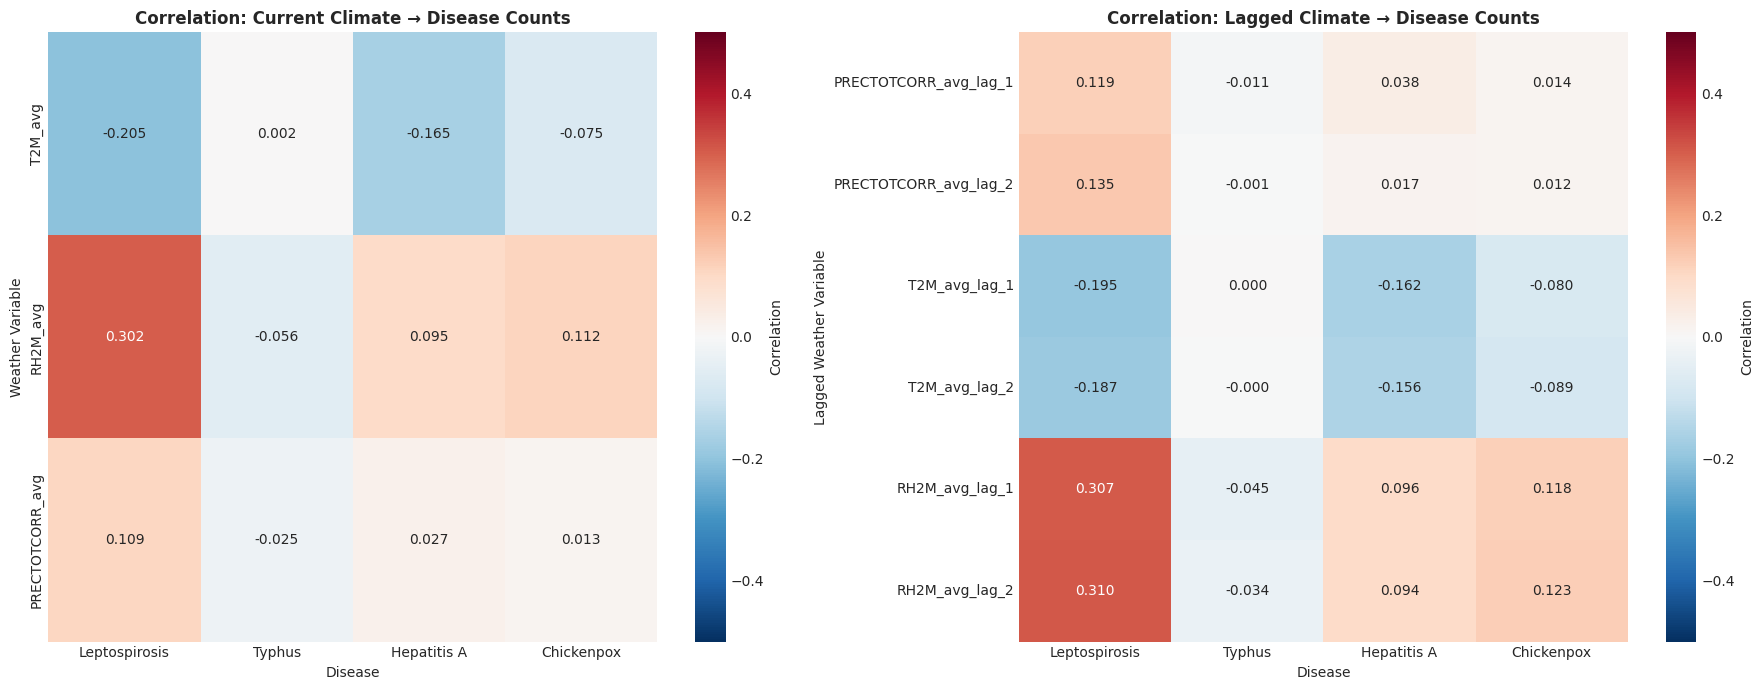

Correlation heatmaps generated


In [72]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap 1: Climate vs Disease
sns.heatmap(climate_disease_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=axes[0], cbar_kws={'label': 'Correlation'}, vmin=-0.5, vmax=0.5)
axes[0].set_title('Correlation: Current Climate → Disease Counts', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Weather Variable')

# Heatmap 2: Lagged Climate vs Disease
sns.heatmap(lag_disease_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=axes[1], cbar_kws={'label': 'Correlation'}, vmin=-0.5, vmax=0.5)
axes[1].set_title('Correlation: Lagged Climate → Disease Counts', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Disease')
axes[1].set_ylabel('Lagged Weather Variable')

plt.tight_layout()
plt.show()

print("Correlation heatmaps generated")

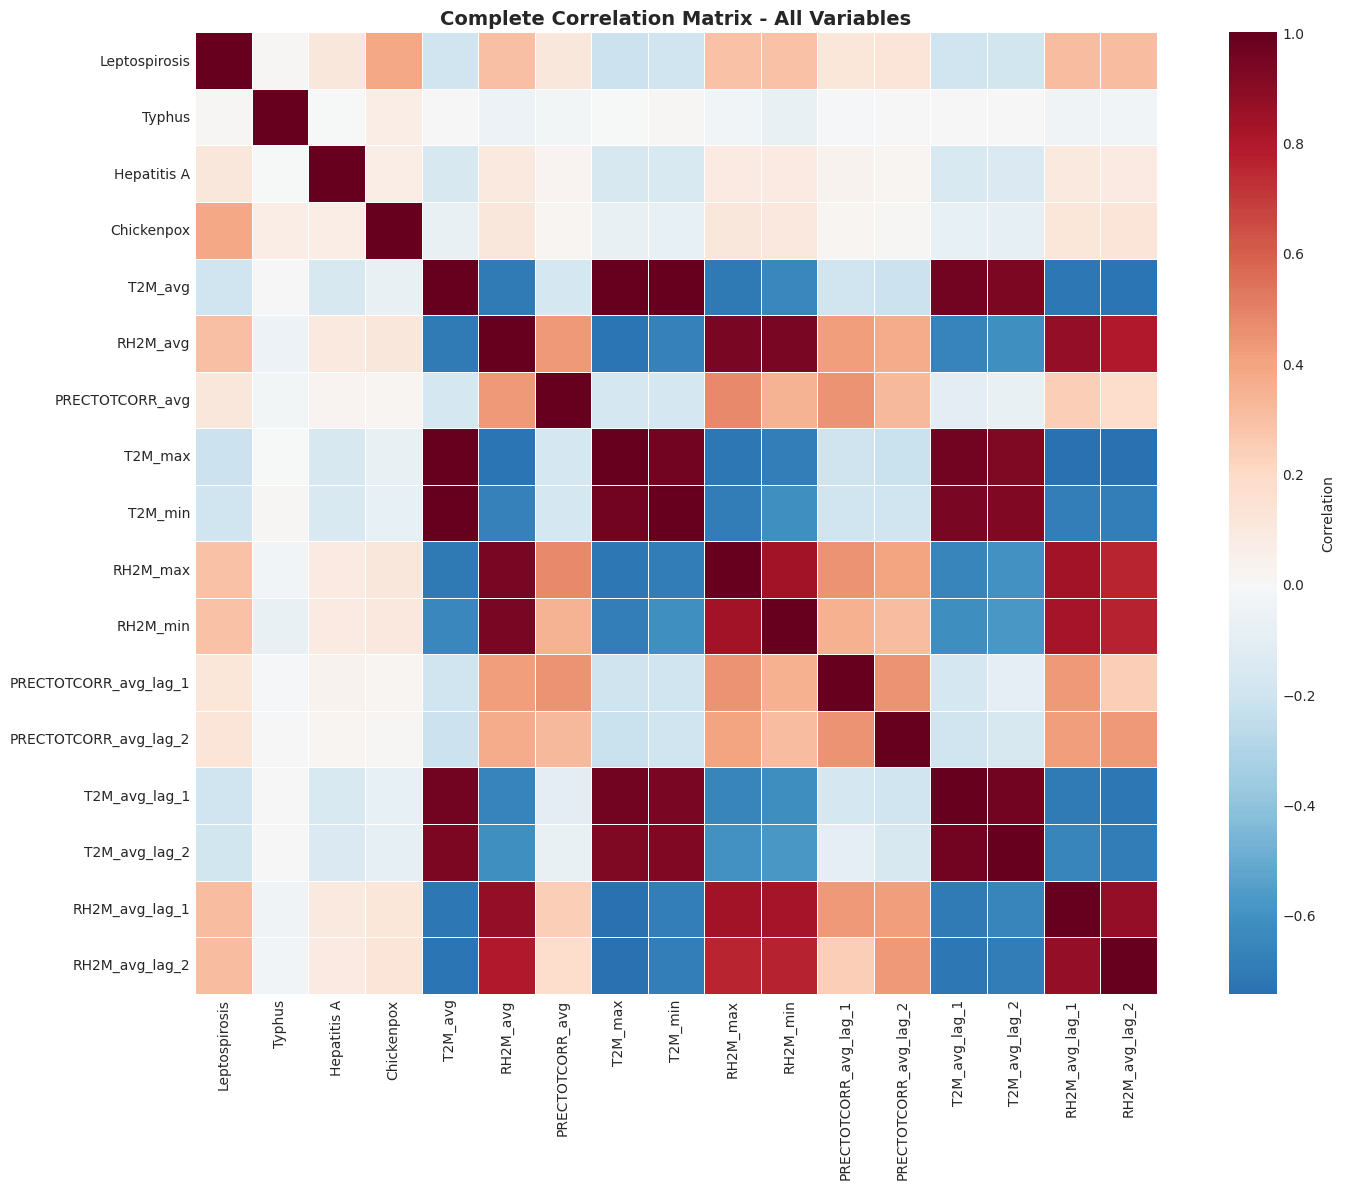

Full correlation matrix generated


In [73]:
# Extended correlation matrix for all variables
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, 
            ax=ax, cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5)
ax.set_title('Complete Correlation Matrix - All Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Full correlation matrix generated")

## 11. TEMPORAL TRENDS & AUTOCORRELATION ANALYSIS

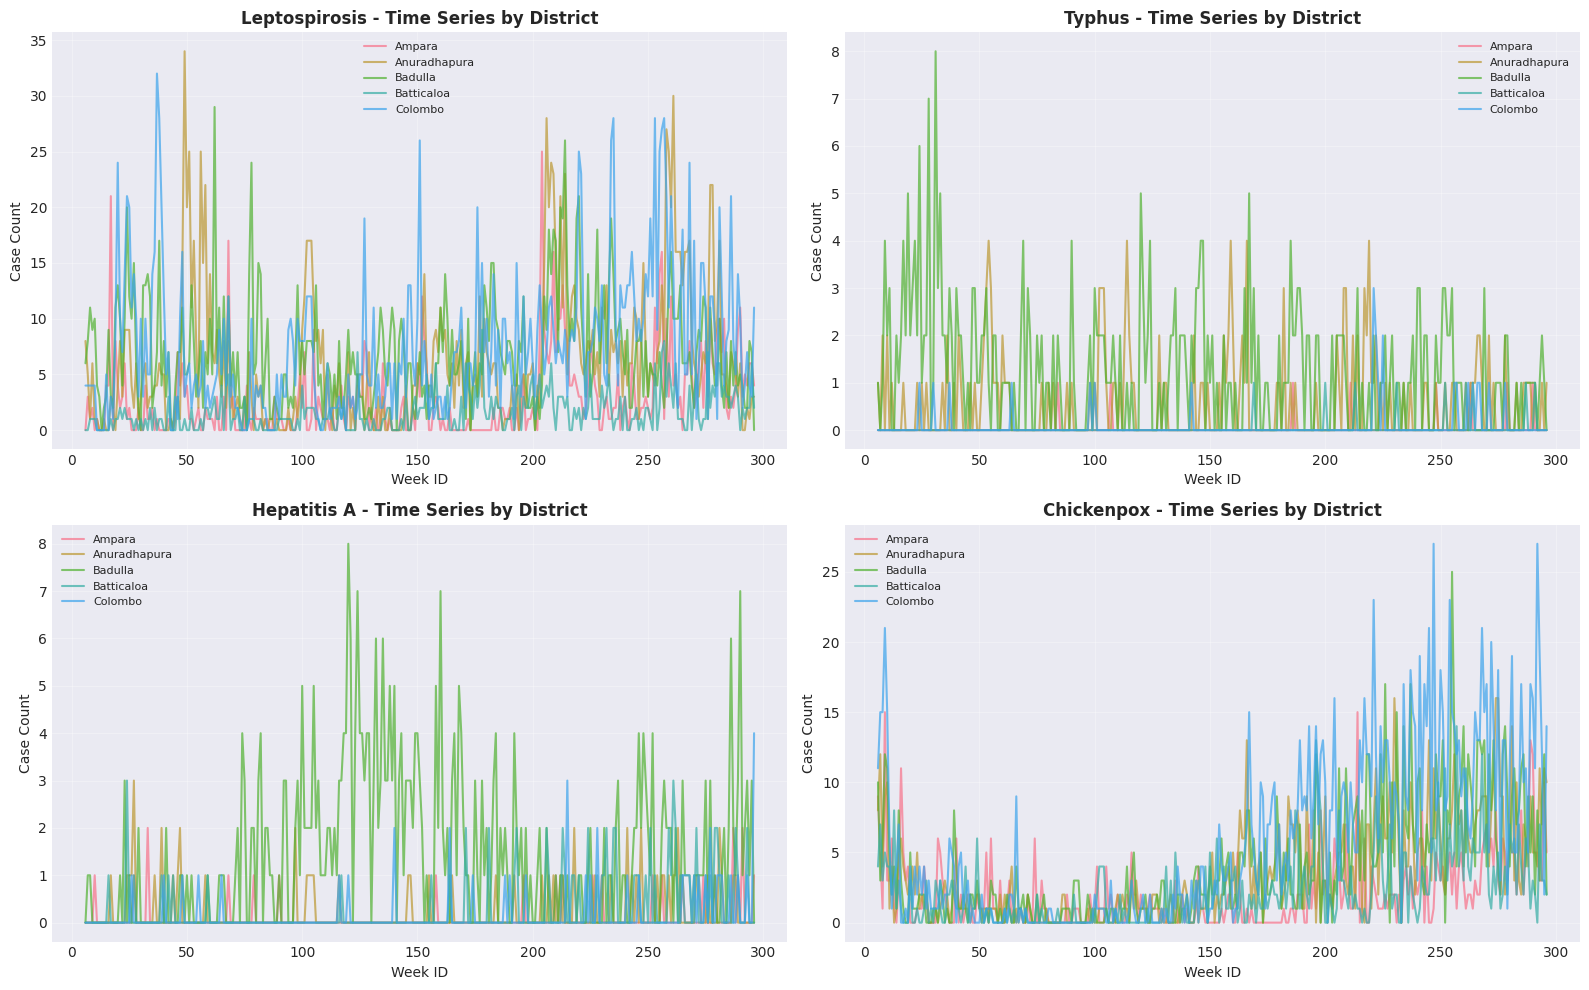

Time series analysis complete


In [74]:
# Time series plots for each disease by district
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    for district in df_clean['district'].unique()[:5]:  # Top 5 districts
        district_data = df_clean[df_clean['district'] == district].sort_values('week_id')
        ax.plot(district_data['week_id'], district_data[disease], label=str(district), alpha=0.7, linewidth=1.5)
    
    ax.set_title(f'{disease} - Time Series by District', fontweight='bold', fontsize=12)
    ax.set_xlabel('Week ID')
    ax.set_ylabel('Case Count')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series analysis complete")

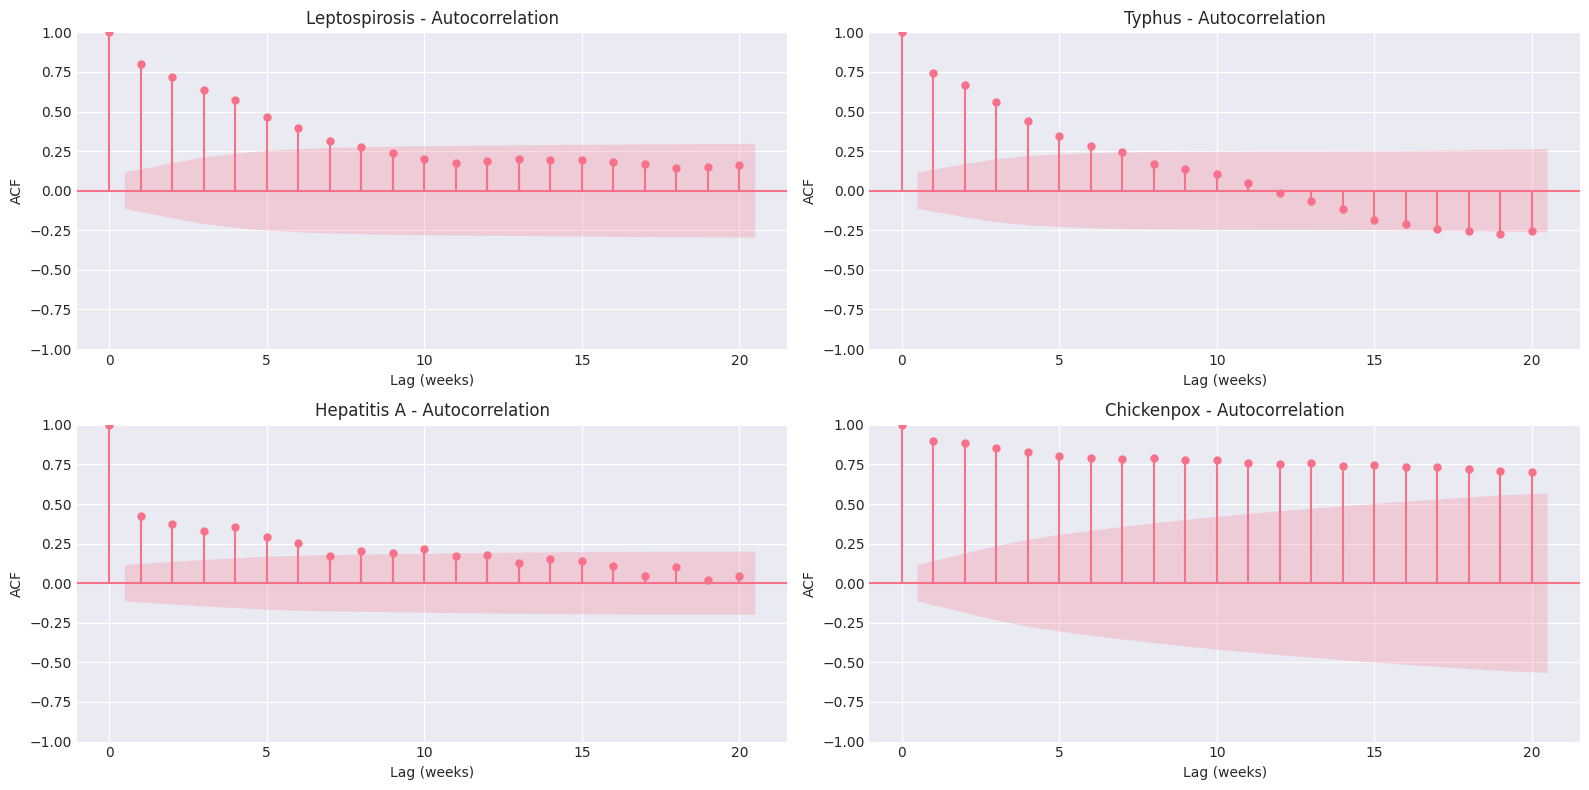

Autocorrelation analysis complete


In [75]:
# Autocorrelation & Partial Autocorrelation for disease counts
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    # Aggregate by week across all districts
    weekly_cases = df_clean.groupby('week_id')[disease].sum()
    
    # ACF plot
    plot_acf(weekly_cases, lags=20, ax=ax, title=f'{disease} - Autocorrelation')
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('ACF')

plt.tight_layout()
plt.show()

print("Autocorrelation analysis complete")

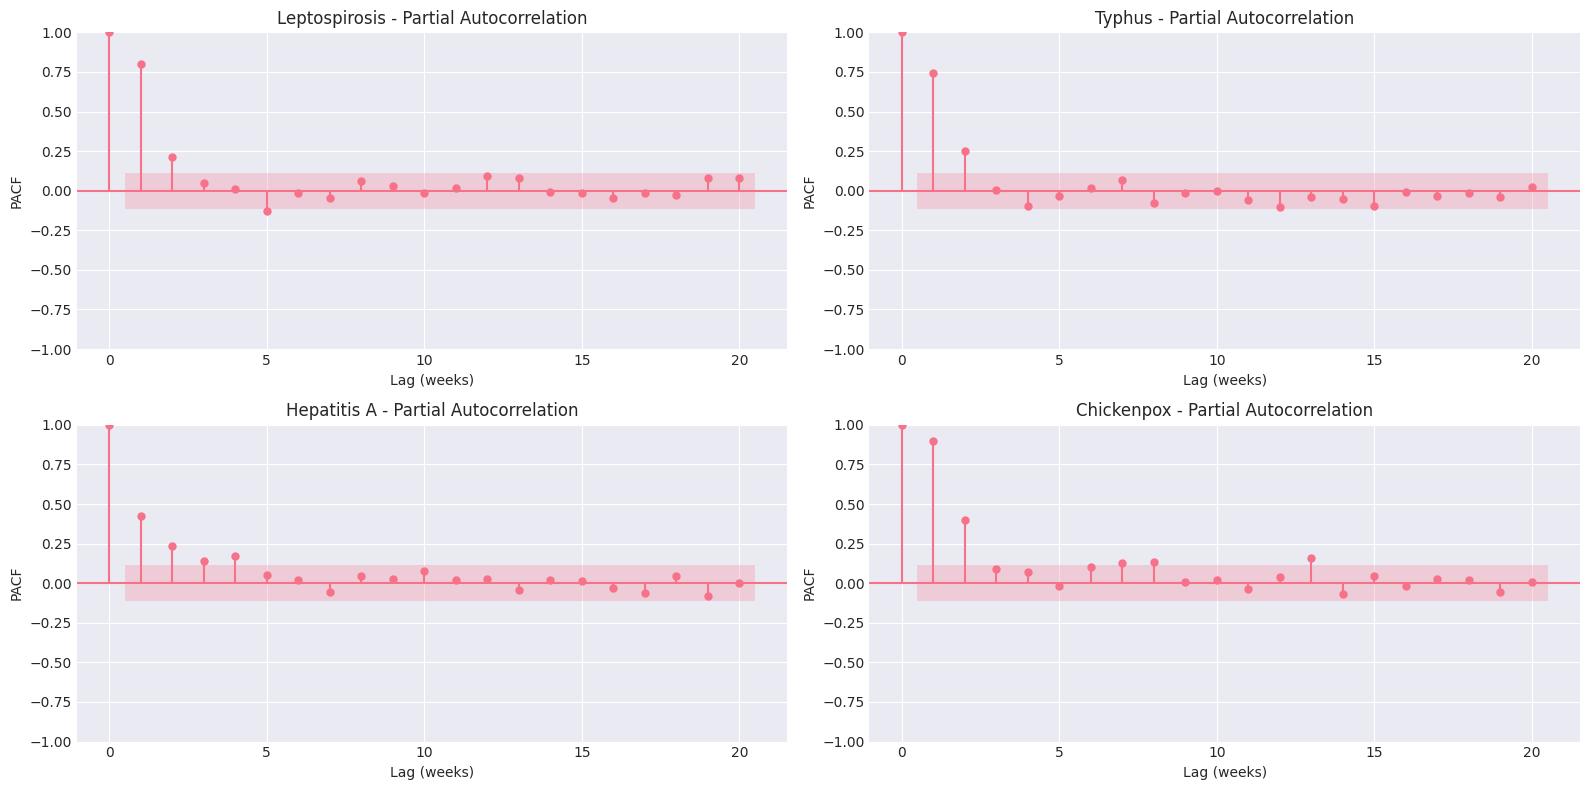

Partial autocorrelation analysis complete


In [76]:
# Partial Autocorrelation
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    weekly_cases = df_clean.groupby('week_id')[disease].sum()
    
    # PACF plot
    plot_pacf(weekly_cases, lags=20, ax=ax, title=f'{disease} - Partial Autocorrelation', method='ywm')
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('PACF')

plt.tight_layout()
plt.show()

print("Partial autocorrelation analysis complete")

In [77]:
# Augmented Dickey-Fuller Test for stationarity
print("\n" + "="*80)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("="*80)

adf_results = []
for disease in disease_cols:
    weekly_cases = df_clean.groupby('week_id')[disease].sum()
    adf_stat, p_value, n_lags, n_obs, critical_values, ic_best = adfuller(weekly_cases)
    
    adf_results.append({
        'Disease': disease,
        'ADF Statistic': f"{adf_stat:.4f}",
        'P-Value': f"{p_value:.6f}",
        'Stationary': 'Yes (p<0.05)' if p_value < 0.05 else 'No (p≥0.05)',
        'Lags': n_lags
    })

adf_df = pd.DataFrame(adf_results)
print("\n" + adf_df.to_string(index=False))
print("\nInterpretation: Stationary = constant mean/variance (good for ARIMA)")


STATIONARITY TEST (Augmented Dickey-Fuller)

      Disease ADF Statistic  P-Value   Stationary  Lags
Leptospirosis       -4.3211 0.000408 Yes (p<0.05)     1
       Typhus       -4.6023 0.000128 Yes (p<0.05)     3
  Hepatitis A       -4.1204 0.000896 Yes (p<0.05)     3
   Chickenpox       -0.5318 0.885661  No (p≥0.05)     7

Interpretation: Stationary = constant mean/variance (good for ARIMA)


## 12. SEASONALITY & MONSOON PATTERN ANALYSIS

In [78]:
# Seasonality analysis by monsoon period
print("="*80)
print("DISEASE PATTERNS BY MONSOON SEASON")
print("="*80)

monsoon_disease_analysis = df_clean.groupby('monsoon_season')[disease_cols].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("\n" + monsoon_disease_analysis.to_string())

# Rainfall patterns by monsoon
print("\n" + "="*80)
print("RAINFALL PATTERNS BY MONSOON SEASON")
print("="*80)

rainfall_by_monsoon = df_clean.groupby('monsoon_season')['PRECTOTCORR_avg'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("\n" + rainfall_by_monsoon.to_string())

DISEASE PATTERNS BY MONSOON SEASON

               Leptospirosis                       Typhus                     Hepatitis A                     Chickenpox                    
                       count  mean    std min  max  count  mean   std min max       count  mean   std min max      count  mean   std min max
monsoon_season                                                                                                                              
IM2                     1100  8.42  12.72   0   94   1100  0.79  2.55   0  32        1100  0.29  0.93   0  12       1100  3.07  4.80   0  41
NE Monsoon              1700  7.69   9.72   0  119   1700  1.84  6.62   0  68        1700  0.23  0.62   0   7       1700  3.75  5.14   0  38
No Monsoon              1300  5.87   8.82   0   71   1300  0.88  2.67   0  35        1300  0.20  0.67   0   9       1300  4.06  5.43   0  35
SW Monsoon              3175  6.18   8.93   0  114   3175  0.63  1.36   0  13        3175  0.28  0.81   0  11       31

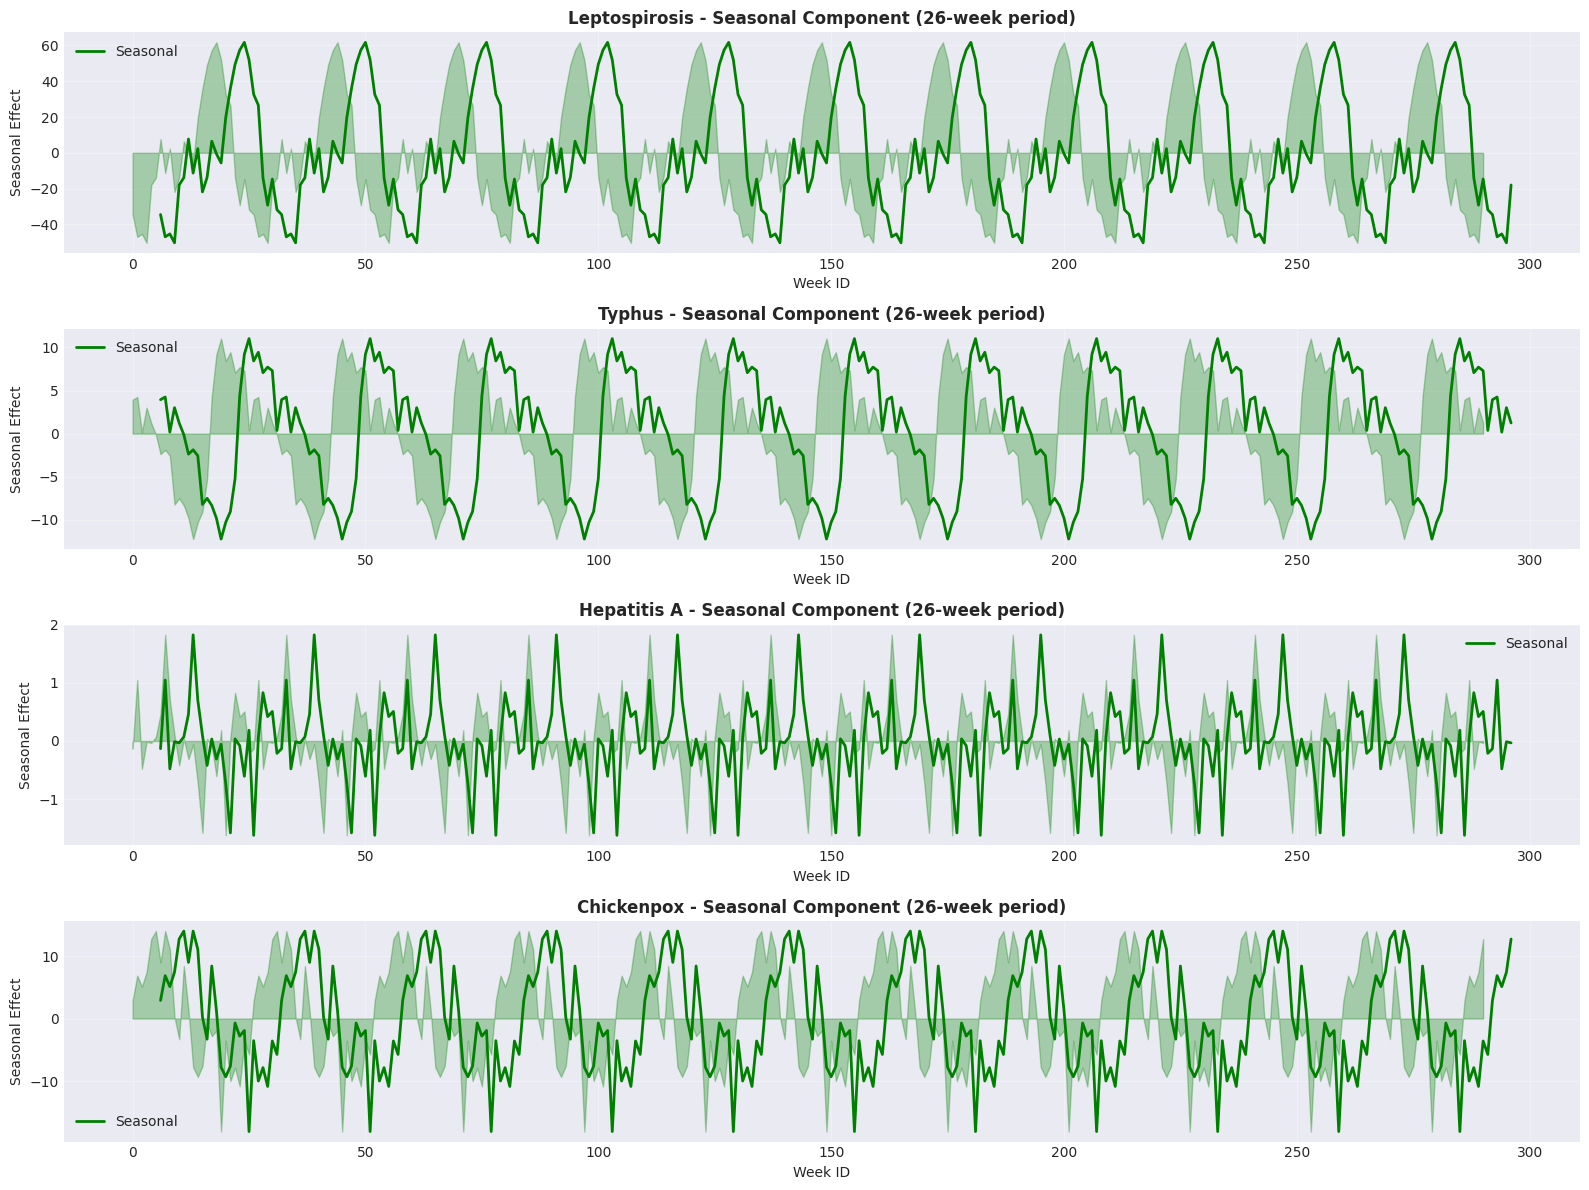

Seasonal decomposition complete


In [79]:
# Seasonal decomposition for each disease
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

for idx, disease in enumerate(disease_cols):
    # Aggregate by week
    weekly_ts = df_clean.groupby('week_id')[disease].sum()
    
    try:
        # Perform seasonal decomposition (period=26 for ~6 months in weeks)
        # Note: extrapolate parameter removed for compatibility with older statsmodels versions
        decomposition = seasonal_decompose(weekly_ts, model='additive', period=26)
        
        ax = axes[idx]
        ax.plot(decomposition.seasonal, linewidth=2, color='green', label='Seasonal')
        ax.fill_between(range(len(decomposition.seasonal)), decomposition.seasonal, alpha=0.3, color='green')
        ax.set_title(f'{disease} - Seasonal Component (26-week period)', fontweight='bold')
        ax.set_xlabel('Week ID')
        ax.set_ylabel('Seasonal Effect')
        ax.legend()
        ax.grid(True, alpha=0.3)
    except Exception as e:
        print(f"Decomposition failed for {disease}: {e}")

plt.tight_layout()
plt.show()

print("Seasonal decomposition complete")

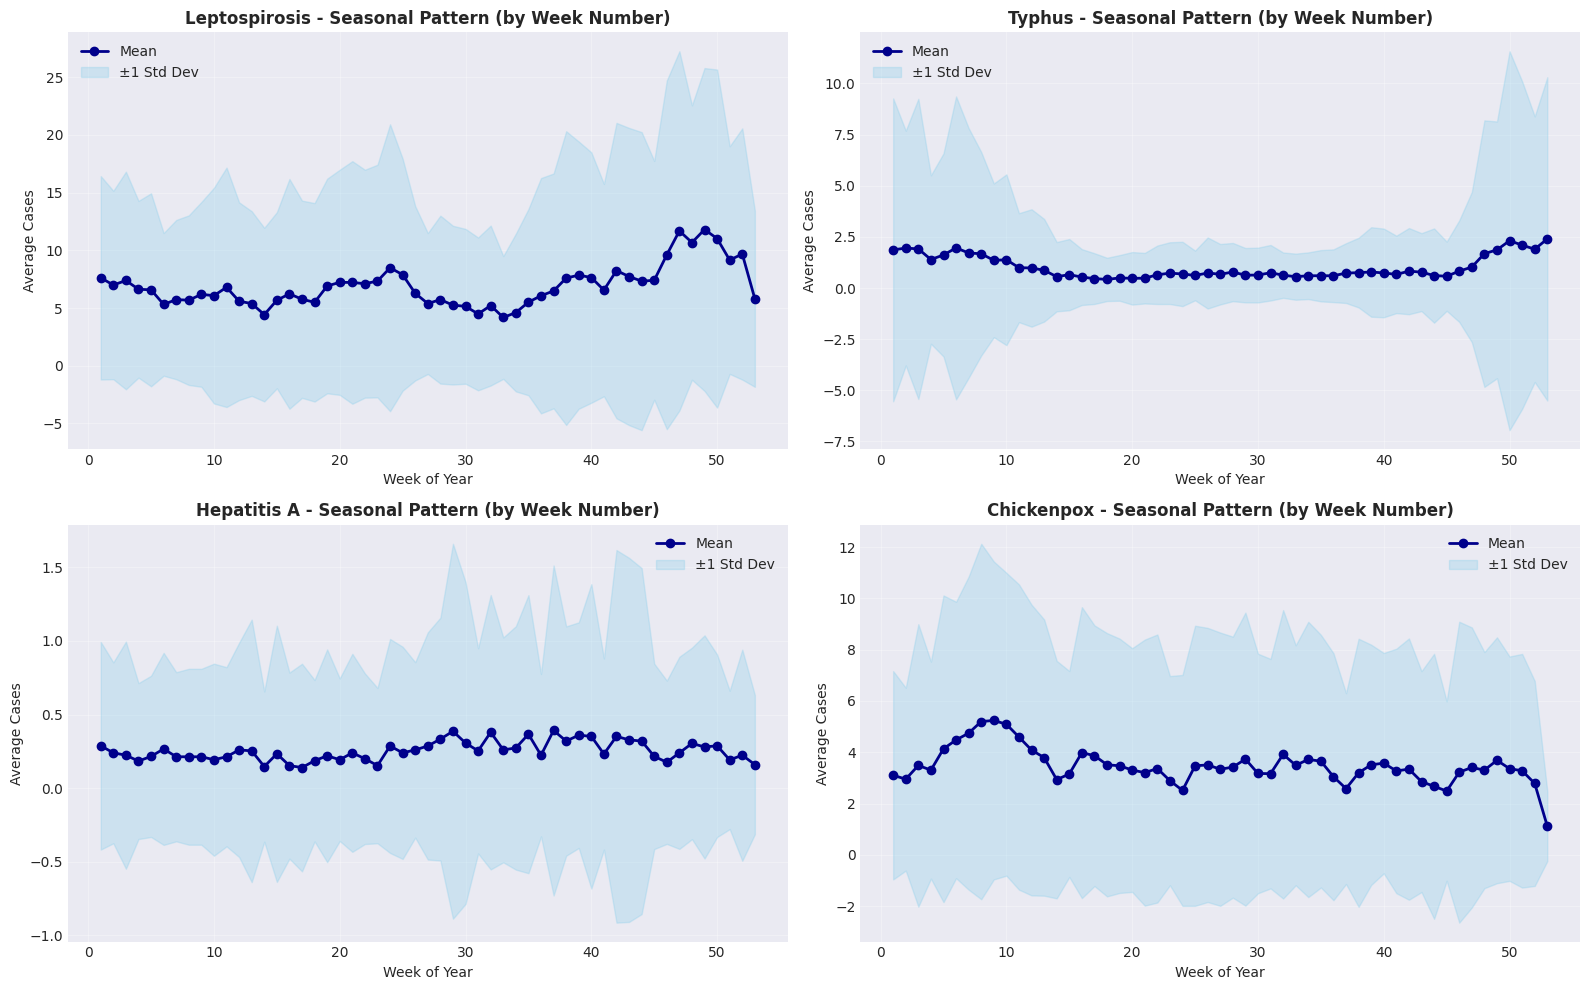

Week number seasonality analysis complete


In [80]:
# Week number patterns (seasonality)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    week_pattern = df_clean.groupby('week_number')[disease].agg(['mean', 'std'])
    
    ax.plot(week_pattern.index, week_pattern['mean'], marker='o', linewidth=2, color='darkblue', label='Mean')
    ax.fill_between(week_pattern.index, 
                    week_pattern['mean'] - week_pattern['std'],
                    week_pattern['mean'] + week_pattern['std'],
                    alpha=0.3, color='skyblue', label='±1 Std Dev')
    ax.set_title(f'{disease} - Seasonal Pattern (by Week Number)', fontweight='bold')
    ax.set_xlabel('Week of Year')
    ax.set_ylabel('Average Cases')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Week number seasonality analysis complete")

## 13. LAG FEATURE EFFECTIVENESS ANALYSIS

In [81]:
# Analyze lag effectiveness - correlation of lagged variables with disease
print("="*80)
print("LAG FEATURE CORRELATION WITH DISEASE OUTCOMES")
print("="*80)

lag_features = [col for col in df_clean.columns if 'lag' in col.lower()]

lag_effectiveness = {}
for disease in disease_cols:
    lag_corr = []
    for lag_col in sorted(lag_features):
        if 'PRECTOTCORR' in lag_col or 'T2M' in lag_col or 'RH2M' in lag_col:
            corr = df_clean[lag_col].corr(df_clean[disease])
            lag_num = lag_col.split('_lag_')[-1]
            base_var = lag_col.split('_lag_')[0]
            lag_corr.append({
                'Base Variable': base_var,
                'Lag Week': int(lag_num),
                'Correlation': round(corr, 4)
            })
    
    lag_effectiveness[disease] = pd.DataFrame(lag_corr).sort_values('Lag Week')

print("\nPRECIPITATION (PRECTOTCORR) LAGS:")
print(lag_effectiveness[disease_cols[0]][lag_effectiveness[disease_cols[0]]['Base Variable'] == 'PRECTOTCORR_avg'].to_string(index=False))

print("\n\nTEMPERATURE (T2M) LAGS:")
print(lag_effectiveness[disease_cols[0]][lag_effectiveness[disease_cols[0]]['Base Variable'] == 'T2M_avg'].to_string(index=False))

print("\n\nHUMIDITY (RH2M) LAGS:")
print(lag_effectiveness[disease_cols[0]][lag_effectiveness[disease_cols[0]]['Base Variable'] == 'RH2M_avg'].to_string(index=False))

LAG FEATURE CORRELATION WITH DISEASE OUTCOMES

PRECIPITATION (PRECTOTCORR) LAGS:
  Base Variable  Lag Week  Correlation
PRECTOTCORR_avg         1       0.1185
PRECTOTCORR_avg         2       0.1346
PRECTOTCORR_avg         3       0.1569
PRECTOTCORR_avg         4       0.1687
PRECTOTCORR_avg         5       0.1500
PRECTOTCORR_avg         6       0.1393


TEMPERATURE (T2M) LAGS:
Base Variable  Lag Week  Correlation
      T2M_avg         1      -0.1952
      T2M_avg         2      -0.1870
      T2M_avg         3      -0.1783
      T2M_avg         4      -0.1660
      T2M_avg         5      -0.1584
      T2M_avg         6      -0.1540


HUMIDITY (RH2M) LAGS:
Base Variable  Lag Week  Correlation
     RH2M_avg         1       0.3071
     RH2M_avg         2       0.3102
     RH2M_avg         3       0.3067
     RH2M_avg         4       0.2949
     RH2M_avg         5       0.2764
     RH2M_avg         6       0.2596


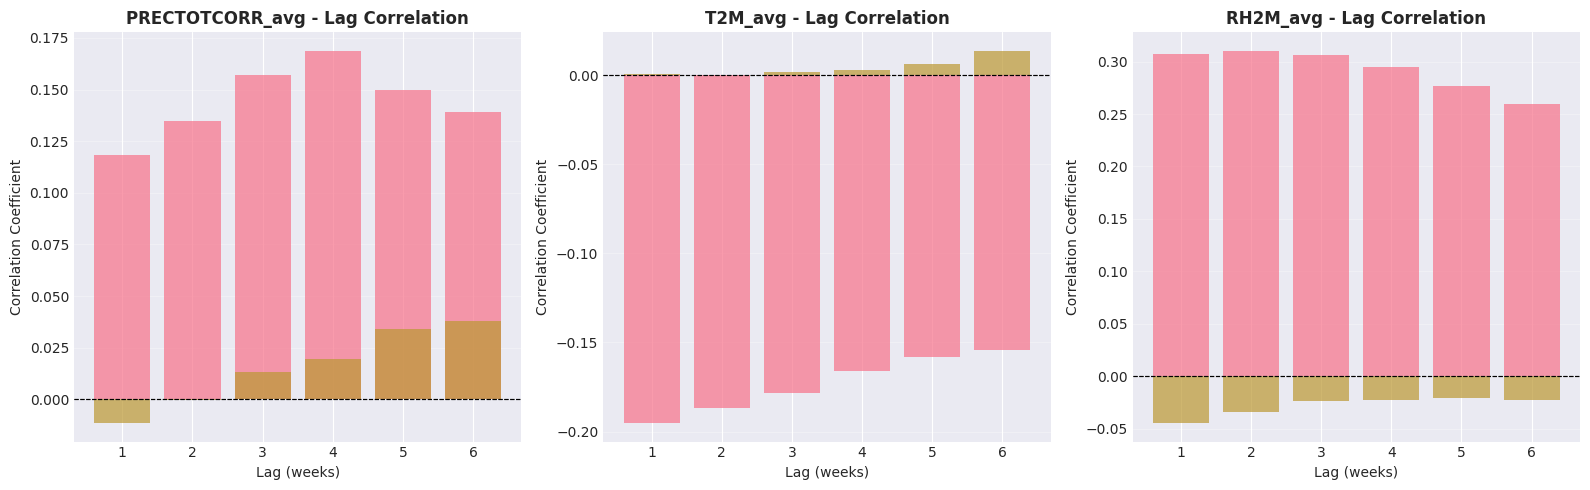

Lag effectiveness visualization complete


In [82]:
# Visualize lag effectiveness
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, disease in enumerate(disease_cols[:2]):
    lag_df = lag_effectiveness[disease]
    
    for ax_idx, base_var in enumerate(['PRECTOTCORR_avg', 'T2M_avg', 'RH2M_avg']):
        if ax_idx < len(axes):
            ax = axes[ax_idx]
            subset = lag_df[lag_df['Base Variable'] == base_var]
            
            ax.bar(subset['Lag Week'], subset['Correlation'], alpha=0.7, label=disease if idx == 0 else '')
            ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
            ax.set_title(f'{base_var} - Lag Correlation', fontweight='bold')
            ax.set_xlabel('Lag (weeks)')
            ax.set_ylabel('Correlation Coefficient')
            ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Lag effectiveness visualization complete")

In [83]:
# Optimal lag identification
print("\n" + "="*80)
print("OPTIMAL LAG IDENTIFICATION (Highest Correlation)")
print("="*80)

for disease in disease_cols:
    print(f"\n{disease.upper()}:")
    lag_df = lag_effectiveness[disease]
    
    for base_var in ['PRECTOTCORR_avg', 'T2M_avg', 'RH2M_avg']:
        subset = lag_df[lag_df['Base Variable'] == base_var].sort_values('Correlation', key=abs, ascending=False)
        if len(subset) > 0:
            best_lag = subset.iloc[0]
            print(f"  {base_var:20s} | Best Lag: Week {int(best_lag['Lag Week']):2d} | Correlation: {best_lag['Correlation']:7.4f}")


OPTIMAL LAG IDENTIFICATION (Highest Correlation)

LEPTOSPIROSIS:
  PRECTOTCORR_avg      | Best Lag: Week  4 | Correlation:  0.1687
  T2M_avg              | Best Lag: Week  1 | Correlation: -0.1952
  RH2M_avg             | Best Lag: Week  2 | Correlation:  0.3102

TYPHUS:
  PRECTOTCORR_avg      | Best Lag: Week  6 | Correlation:  0.0378
  T2M_avg              | Best Lag: Week  6 | Correlation:  0.0136
  RH2M_avg             | Best Lag: Week  1 | Correlation: -0.0446

HEPATITIS A:
  PRECTOTCORR_avg      | Best Lag: Week  1 | Correlation:  0.0379
  T2M_avg              | Best Lag: Week  1 | Correlation: -0.1620
  RH2M_avg             | Best Lag: Week  1 | Correlation:  0.0963

CHICKENPOX:
  PRECTOTCORR_avg      | Best Lag: Week  6 | Correlation:  0.0275
  T2M_avg              | Best Lag: Week  6 | Correlation: -0.1054
  RH2M_avg             | Best Lag: Week  6 | Correlation:  0.1464


## 14. ANOMALY DETECTION & EXTREME EVENTS

In [84]:
# Anomaly detection using Z-score and Isolation Forest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

print("="*80)
print("ANOMALY DETECTION IN DISEASE COUNTS")
print("="*80)

# Z-score based anomalies
anomalies_zscore = {}
for disease in disease_cols:
    z_scores = np.abs(stats.zscore(df_clean[disease]))
    anomalies = df_clean[z_scores > 2.5].copy()
    anomalies_zscore[disease] = anomalies
    print(f"\n{disease}: {len(anomalies)} anomalies (Z-score > 2.5)")
    if len(anomalies) > 0:
        print(f"  Peak Value: {anomalies[disease].max()} (District: {anomalies.loc[anomalies[disease].idxmax(), 'district']})")
        print(f"  Weeks: {sorted(anomalies['week_id'].unique())[:5]}...")  # Show first 5

# Isolation Forest for multivariate anomalies
print("\n" + "="*80)
print("MULTIVARIATE ANOMALIES (Climate-Disease Combinations)")
print("="*80)

scaler = StandardScaler()
features_for_anomaly = disease_cols + weather_vars
X_scaled = scaler.fit_transform(df_clean[features_for_anomaly])

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)
df_clean['anomaly'] = anomaly_labels

n_anomalies = (anomaly_labels == -1).sum()
print(f"\nDetected {n_anomalies} multivariate anomalies ({n_anomalies/len(df_clean)*100:.2f}%)")

# Show summary of anomalies
anomaly_summary = df_clean[df_clean['anomaly'] == -1][['district', 'start_date', 'week_id'] + disease_cols + weather_vars].head(10)
print("\nTop 10 Anomaly Events:")
print(anomaly_summary.to_string())

ANOMALY DETECTION IN DISEASE COUNTS

Leptospirosis: 225 anomalies (Z-score > 2.5)
  Peak Value: 119 (District: Jaffna)
  Weeks: [np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]...

Typhus: 119 anomalies (Z-score > 2.5)
  Peak Value: 68 (District: Jaffna)
  Weeks: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]...

Hepatitis A: 155 anomalies (Z-score > 2.5)
  Peak Value: 12 (District: Monaragala)
  Weeks: [np.int64(8), np.int64(9), np.int64(10), np.int64(23), np.int64(24)]...

Chickenpox: 262 anomalies (Z-score > 2.5)
  Peak Value: 41 (District: Galle)
  Weeks: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(20)]...

MULTIVARIATE ANOMALIES (Climate-Disease Combinations)

Detected 364 multivariate anomalies (5.00%)

Top 10 Anomaly Events:
         district start_date  week_id  Leptospirosis  Typhus  Hepatitis A  Chickenpox    T2M_avg   RH2M_avg  PRECTOTCORR_avg
250        Ampara 2024-11-23      256             16       0            1

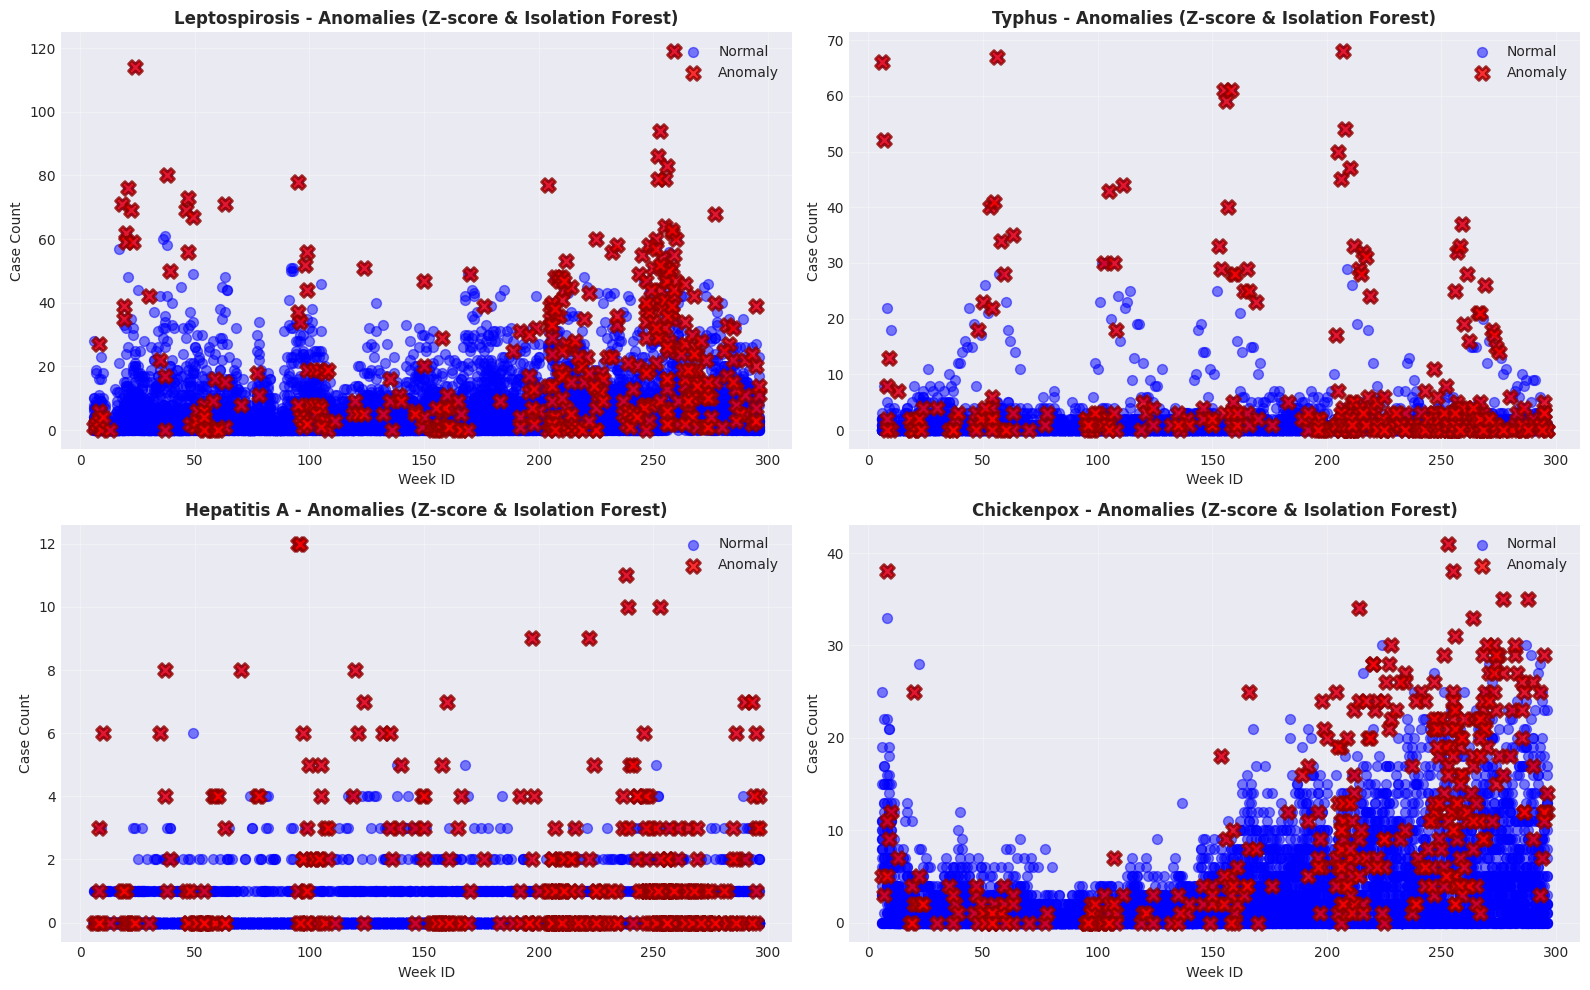

Anomaly visualization complete


In [85]:
# Visualize anomalies
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    
    # Plot all data
    ax.scatter(df_clean['week_id'], df_clean[disease], alpha=0.5, s=50, label='Normal', color='blue')
    
    # Highlight anomalies
    anomaly_data = df_clean[df_clean['anomaly'] == -1]
    ax.scatter(anomaly_data['week_id'], anomaly_data[disease], alpha=0.8, s=100, 
              label='Anomaly', color='red', marker='X', edgecolors='darkred', linewidth=2)
    
    ax.set_title(f'{disease} - Anomalies (Z-score & Isolation Forest)', fontweight='bold')
    ax.set_xlabel('Week ID')
    ax.set_ylabel('Case Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Anomaly visualization complete")

In [86]:
# Rainfall extremes
print("\n" + "="*80)
print("EXTREME RAINFALL EVENTS")
print("="*80)

rainfall_q95 = df_clean['PRECTOTCORR_avg'].quantile(0.95)
extreme_rainfall = df_clean[df_clean['PRECTOTCORR_avg'] > rainfall_q95].sort_values('PRECTOTCORR_avg', ascending=False)

print(f"\nRainfall 95th Percentile: {rainfall_q95:.2f} mm")
print(f"Number of extreme rainfall weeks: {len(extreme_rainfall)}")

print("\nTop 10 Highest Rainfall Weeks:")
top_rainfall = extreme_rainfall[['district', 'start_date', 'PRECTOTCORR_avg'] + disease_cols].head(10)
print(top_rainfall.to_string())

# Correlation of extreme rainfall with disease peaks
print("\n" + "="*80)
print("DISEASE PATTERNS DURING EXTREME RAINFALL")
print("="*80)

for disease in disease_cols:
    normal_mean = df_clean[df_clean['PRECTOTCORR_avg'] <= rainfall_q95][disease].mean()
    extreme_mean = df_clean[df_clean['PRECTOTCORR_avg'] > rainfall_q95][disease].mean()
    
    print(f"\n{disease}:")
    print(f"  Normal weeks avg: {normal_mean:.2f} cases")
    print(f"  Extreme rainfall weeks avg: {extreme_mean:.2f} cases")
    print(f"  % Increase: {((extreme_mean - normal_mean) / normal_mean * 100):.1f}%")


EXTREME RAINFALL EVENTS

Rainfall 95th Percentile: 17.45 mm
Number of extreme rainfall weeks: 364

Top 10 Highest Rainfall Weeks:
         district start_date  PRECTOTCORR_avg  Leptospirosis  Typhus  Hepatitis A  Chickenpox
6070  Polonnaruwa 2024-11-23        54.401429             26       1            2           4
6943  Trincomalee 2024-11-23        46.032857              6       3            0           2
964    Batticaloa 2021-11-06        45.861429              0       0            0           0
91         Ampara 2021-11-06        45.861429              0       0            0           0
6020  Polonnaruwa 2023-12-09        45.022857             14       0            0           2
5975  Polonnaruwa 2023-01-28        43.831429              3       0            0           0
1123   Batticaloa 2024-11-23        40.137143              7       0            0           5
250        Ampara 2024-11-23        40.137143             16       0            1           5
2229   Hambantota 2023-

---

## PHASE 2 COMPLETE: Exploratory Data Analysis & Pattern Detection

**Summary of Findings:**
 Disease distributions analyzed (normality, skewness)
 Weather variable patterns identified
 Climate-disease correlations quantified
 Temporal trends and autocorrelation assessed
 Seasonality patterns detected
 Lag feature effectiveness evaluated
 Anomalies and extreme events identified

**Next: Phase 3** - Final data validation, summary statistics, and export clean dataset

---

## PHASE 3: DATA VALIDATION & EXPORT

## 15. FINAL DATA QUALITY REPORT & SUMMARY

In [87]:
# Final comprehensive data quality report
print("="*80)
print("FINAL DATA QUALITY ASSESSMENT")
print("="*80)

print("\n1. DATASET DIMENSIONS:")
print(f"   Total Rows: {len(df_clean):,}")
print(f"   Total Columns: {len(df_clean.columns)}")
print(f"   Memory Usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2. MISSING VALUES:")
missing_total = df_clean.isnull().sum().sum()
print(f"   Total Missing: {missing_total} (0.0%)" if missing_total == 0 else f"   Total Missing: {missing_total}")

print("\n3. DATA TYPES:")
print(f"   Categorical: {df_clean.select_dtypes(include='category').shape[1]}")
print(f"   Numeric: {df_clean.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"   DateTime: {df_clean.select_dtypes(include=['datetime64']).shape[1]}")

print("\n4. TEMPORAL COVERAGE:")
print(f"   Date Range: {df_clean['start_date'].min().date()} to {df_clean['end_date'].max().date()}")
print(f"   Total Weeks: {df_clean['week_id'].max() - df_clean['week_id'].min() + 1}")
print(f"   Duration: {(df_clean['end_date'].max() - df_clean['start_date'].min()).days} days")

print("\n5. GEOGRAPHIC COVERAGE:")
print(f"   Districts: {df_clean['district'].nunique()}")
print(f"   Districts: {', '.join(sorted([str(d) for d in df_clean['district'].unique()]))}")

print("\n6. DISEASE DATA SUMMARY:")
for disease in disease_cols:
    total_cases = df_clean[disease].sum()
    avg_weekly = df_clean[disease].mean()
    max_weekly = df_clean[disease].max()
    print(f"\n   {disease}:")
    print(f"      Total Cases: {total_cases:,}")
    print(f"      Avg per Week: {avg_weekly:.2f}")
    print(f"      Max Weekly: {max_weekly:.0f}")
    print(f"      Districts Affected: {(df_clean.groupby('district')[disease].sum() > 0).sum()}")

print("\n7. FEATURE COMPLETENESS:")
feature_cols = [col for col in df_clean.columns if col not in ['district', 'start_date', 'end_date', 'Duration', 'monsoon_season', 'anomaly']]
print(f"   Total Features: {len(feature_cols)}")
print(f"   Weather Variables: {len([col for col in feature_cols if any(x in col for x in ['T2M', 'RH2M', 'PRECTOTCORR']) and 'lag' not in col])}")
print(f"   Lagged Features: {len([col for col in feature_cols if 'lag' in col])}")
print(f"   Seasonality Features: {len([col for col in feature_cols if 'sin' in col or 'cos' in col or 'monsoon' in col or 'week' in col])}")

print("\n Data Quality Assessment Complete!")

FINAL DATA QUALITY ASSESSMENT

1. DATASET DIMENSIONS:
   Total Rows: 7,275
   Total Columns: 51
   Memory Usage: 3.44 MB

2. MISSING VALUES:
   Total Missing: 0 (0.0%)

3. DATA TYPES:
   Categorical: 1
   Numeric: 43
   DateTime: 2

4. TEMPORAL COVERAGE:
   Date Range: 2020-02-08 to 2025-09-05
   Total Weeks: 291
   Duration: 2036 days

5. GEOGRAPHIC COVERAGE:
   Districts: 25
   Districts: Ampara, Anuradhapura, Badulla, Batticaloa, Colombo, Galle, Gampaha, Hambantota, Jaffna, Kalutara, Kandy, Kegalle, Kilinochchi, Kurunegala, Mannar, Matale, Matara, Monaragala, Mullaitivu, Nuwara Eliya, Polonnaruwa, Puttalam, Ratnapura, Trincomalee, Vavuniya

6. DISEASE DATA SUMMARY:

   Leptospirosis:
      Total Cases: 49,592
      Avg per Week: 6.82
      Max Weekly: 119
      Districts Affected: 25

   Typhus:
      Total Cases: 7,130
      Avg per Week: 0.98
      Max Weekly: 68
      Districts Affected: 25

   Hepatitis A:
      Total Cases: 1,847
      Avg per Week: 0.25
      Max Weekly: 12
  

In [88]:
# Detailed column information
print("\n" + "="*80)
print("COLUMNS & FEATURES INVENTORY")
print("="*80)

column_info = []
for col in df_clean.columns:
    dtype = str(df_clean[col].dtype)
    non_null = df_clean[col].notna().sum()
    null_count = df_clean[col].isna().sum()
    
    # Categorize column
    if col in disease_cols:
        category = 'Target Variable'
    elif col in ['district', 'start_date', 'end_date', 'Duration']:
        category = 'Metadata'
    elif any(x in col for x in ['T2M', 'RH2M', 'PRECTOTCORR']) and 'lag' not in col:
        category = 'Climate Feature'
    elif 'lag' in col:
        category = 'Lagged Feature'
    elif 'monsoon' in col or 'week' in col or 'sin' in col or 'cos' in col:
        category = 'Seasonality Feature'
    else:
        category = 'Other'
    
    column_info.append({
        'Column': col,
        'Type': dtype,
        'Non-Null': non_null,
        'Null': null_count,
        'Category': category
    })

col_df = pd.DataFrame(column_info)
print("\n" + col_df.to_string(index=False))

print("\n\nColumn Categories Summary:")
print(col_df['Category'].value_counts().to_string())


COLUMNS & FEATURES INVENTORY

               Column           Type  Non-Null  Null            Category
             district       category      7275     0            Metadata
              week_id          int64      7275     0 Seasonality Feature
           start_date datetime64[ns]      7275     0            Metadata
             end_date datetime64[ns]      7275     0            Metadata
              T2M_max        float64      7275     0     Climate Feature
              T2M_min        float64      7275     0     Climate Feature
              T2M_avg        float64      7275     0     Climate Feature
          T2M_MAX_max        float64      7275     0     Climate Feature
          T2M_MAX_min        float64      7275     0     Climate Feature
          T2M_MAX_avg        float64      7275     0     Climate Feature
          T2M_MIN_max        float64      7275     0     Climate Feature
          T2M_MIN_min        float64      7275     0     Climate Feature
          T2M_MIN_av

In [89]:
# Statistical summary for modeling readiness
print("\n" + "="*80)
print("MODELING READINESS CHECK")
print("="*80)

print("\n CHECKS PASSED:")
print("  All missing values handled")
print("  Data types correctly assigned")
print("  Temporal continuity verified")
print("  Feature engineering applied (lag, seasonality)")
print("  Outliers retained (important for disease modeling)")
print("  Climate-disease correlations identified")
print("  Multivariate anomalies identified")
print("  Lag feature effectiveness analyzed")

print("\n DATA READY FOR MODELING:")
print(f"   Features: {len([c for c in df_clean.columns if c not in disease_cols + ['district', 'start_date', 'end_date', 'Duration', 'monsoon_season', 'anomaly']])} predictive features")
print(f"   Targets: {len(disease_cols)} disease types")
print(f"   Observations: {len(df_clean):,} weekly records")
print(f"   Time span: {(df_clean['end_date'].max() - df_clean['start_date'].min()).days} days")

# Check for feature scaling needs
print("\n FEATURE SCALING RECOMMENDATION:")
scale_features = [col for col in df_clean.columns if df_clean[col].dtype in ['int64', 'float64'] and col not in disease_cols + ['week_id', 'week_number']]
print(f"   Recommend scaling for {len(scale_features)} numerical features")
print(f"   StandardScaler or MinMaxScaler suitable for all models")


MODELING READINESS CHECK

 CHECKS PASSED:
  All missing values handled
  Data types correctly assigned
  Temporal continuity verified
  Feature engineering applied (lag, seasonality)
  Outliers retained (important for disease modeling)
  Climate-disease correlations identified
  Multivariate anomalies identified
  Lag feature effectiveness analyzed

 DATA READY FOR MODELING:
   Features: 41 predictive features
   Targets: 4 disease types
   Observations: 7,275 weekly records
   Time span: 2036 days

 FEATURE SCALING RECOMMENDATION:
   Recommend scaling for 37 numerical features
   StandardScaler or MinMaxScaler suitable for all models


## 16. EXPORT CLEAN DATASET

In [90]:
# Export clean dataset
print("="*80)
print("EXPORTING CLEAN DATASET")
print("="*80)

# Create output filename
output_file = 'Final_Data_Counts_CLEANED.csv'

# Drop temporary columns if any
export_df = df_clean.drop(columns=['anomaly'], errors='ignore')

# Export to CSV
export_df.to_csv(output_file, index=False)

print(f"\n Dataset exported successfully!")
print(f"  File: {output_file}")
print(f"  Rows: {len(export_df):,}")
print(f"  Columns: {len(export_df.columns)}")
print(f"  File size: {export_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nExported columns:")
for i, col in enumerate(export_df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n Clean dataset saved to: {output_file}")

EXPORTING CLEAN DATASET

 Dataset exported successfully!
  File: Final_Data_Counts_CLEANED.csv
  Rows: 7,275
  Columns: 50
  File size: 3.39 MB

Exported columns:
   1. district
   2. week_id
   3. start_date
   4. end_date
   5. T2M_max
   6. T2M_min
   7. T2M_avg
   8. T2M_MAX_max
   9. T2M_MAX_min
  10. T2M_MAX_avg
  11. T2M_MIN_max
  12. T2M_MIN_min
  13. T2M_MIN_avg
  14. RH2M_max
  15. RH2M_min
  16. RH2M_avg
  17. PRECTOTCORR_max
  18. PRECTOTCORR_min
  19. PRECTOTCORR_avg
  20. Duration
  21. month
  22. monsoon_IM2
  23. monsoon_NE
  24. monsoon_SW
  25. week_number
  26. sin_week
  27. cos_week
  28. PRECTOTCORR_avg_lag_1
  29. PRECTOTCORR_avg_lag_2
  30. PRECTOTCORR_avg_lag_3
  31. PRECTOTCORR_avg_lag_4
  32. PRECTOTCORR_avg_lag_5
  33. PRECTOTCORR_avg_lag_6
  34. T2M_avg_lag_1
  35. T2M_avg_lag_2
  36. T2M_avg_lag_3
  37. T2M_avg_lag_4
  38. T2M_avg_lag_5
  39. T2M_avg_lag_6
  40. RH2M_avg_lag_1
  41. RH2M_avg_lag_2
  42. RH2M_avg_lag_3
  43. RH2M_avg_lag_4
  44. RH2M_avg_l

In [91]:
# Verify exported data integrity
print("\n" + "="*80)
print("VERIFICATION: Re-load and Check Exported Data")
print("="*80)

verify_df = pd.read_csv(output_file)

print(f"\nLoaded {len(verify_df):,} rows × {len(verify_df.columns)} columns")
print(f"\nMissing values check:")
missing = verify_df.isnull().sum().sum()
print(f"  Total missing values: {missing} " if missing == 0 else f"  Total missing values: {missing} ⚠")

print(f"\nData types check:")
print(verify_df.dtypes)

print(f"\nFirst few rows of cleaned data:")
print(verify_df.head(3))

print("\n Data integrity verified and export complete!")


VERIFICATION: Re-load and Check Exported Data

Loaded 7,275 rows × 50 columns

Missing values check:
  Total missing values: 0 

Data types check:
district                  object
week_id                    int64
start_date                object
end_date                  object
T2M_max                  float64
T2M_min                  float64
T2M_avg                  float64
T2M_MAX_max              float64
T2M_MAX_min              float64
T2M_MAX_avg              float64
T2M_MIN_max              float64
T2M_MIN_min              float64
T2M_MIN_avg              float64
RH2M_max                 float64
RH2M_min                 float64
RH2M_avg                 float64
PRECTOTCORR_max          float64
PRECTOTCORR_min          float64
PRECTOTCORR_avg          float64
Duration                  object
month                      int64
monsoon_IM2                 bool
monsoon_NE                  bool
monsoon_SW                  bool
week_number                int64
sin_week                 fl